# Phase 1 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Shallow EDA
> **Goal:** Understand what the data contains. No thesis at this stage.
>
> Steps: 1.1 Data Quality Audit ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â· 1.2 FK Validation ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â· 1.3 Descriptive Landscape ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â· 1.4 Observations

In [73]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from src.loaders import load_all_tables

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']
FIG_DIR = '../figures/'

tables = load_all_tables()
sales        = tables['sales']
customers    = tables['customers']
orders       = tables['orders']
order_items  = tables['order_items']
products     = tables['products']
promotions   = tables['promotions']
shipments    = tables['shipments']
returns      = tables['returns']
reviews      = tables['reviews']
payments     = tables['payments']
geography    = tables['geography']
inventory    = tables['inventory']
web_traffic  = tables['web_traffic']

print('Tables loaded:', list(tables.keys()))

Tables loaded: ['sales', 'customers', 'orders', 'order_items', 'products', 'promotions', 'shipments', 'returns', 'reviews', 'payments', 'geography', 'inventory', 'web_traffic']


---
## Step 1.1 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Data Quality Audit

In [74]:
def audit_table(name: str, df: pd.DataFrame) -> dict:
    date_cols = [c for c in df.columns if df[c].dtype == 'datetime64[ns]']
    date_range = (
        f"{df[date_cols[0]].min().date()} ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ {df[date_cols[0]].max().date()}"
        if date_cols else 'N/A'
    )
    missing_pct = df.isna().mean().mul(100).round(1)
    top_missing = (
        missing_pct[missing_pct > 0].sort_values(ascending=False).to_dict()
        if missing_pct.any() else {}
    )
    return {
        'table': name,
        'rows': df.shape[0],
        'cols': df.shape[1],
        'mem_MB': round(df.memory_usage(deep=True).sum() / 1e6, 1),
        'date_range': date_range,
        'missing_cols': len(top_missing),
        'top_missing': str(top_missing)[:80] if top_missing else 'ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â',
        'duplicates': int(df.duplicated().sum()),
    }

audit_rows = [audit_table(name, df) for name, df in tables.items()]
quality = pd.DataFrame(audit_rows)
quality

,table,rows,cols,mem_MB,date_range,missing_cols,top_missing,duplicates
0,sales,3833,3,0.1,2012-07-04 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-31,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
1,customers,121930,7,29.5,2012-01-17 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-31,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
2,orders,646945,8,162.9,2012-07-04 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-31,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
3,order_items,714669,7,76.1,N/A,2,"{'promo_id_2': 100.0, 'promo_id': 61.3}",0
4,products,2412,10,0.8,N/A,2,"{'Unnamed: 8': 100.0, 'Unnamed: 9': 99.0}",0
5,promotions,50,10,0.0,2013-01-31 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-11-18,1,{'applicable_category': 80.0},0
6,shipments,566067,4,15.9,2012-07-04 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-29,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
7,returns,39939,7,6.1,2012-07-11 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-31,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
8,reviews,113551,7,17.3,2012-07-10 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ 2022-12-31,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0
9,payments,646945,4,50.4,N/A,0,ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â,0


In [75]:
# Per-column missing breakdown for tables with nulls
print('=== Missing value detail ===')
for name, df in tables.items():
    missing = df.isna().mean().mul(100).round(1)
    missing = missing[missing > 0]
    if not missing.empty:
        print(f'\n{name}:')
        print(missing.to_string())

=== Missing value detail ===

order_items:
promo_id       61.3
promo_id_2    100.0

products:
Unnamed: 8    100.0
Unnamed: 9     99.0

promotions:
applicable_category    80.0


In [76]:
# Numeric summary for key tables
print('--- sales ---')
display(sales.describe().round(2))
print('\n--- orders ---')
display(orders.describe(include='all').T[['count','unique','top','mean','min','max']].dropna(how='all'))

--- sales ---


,Date,Revenue,COGS
count,3833,3833.00,3833.00
mean,2017-10-02 00:00:00,4286584.03,3695134.49
min,2012-07-04 00:00:00,279813.94,236576.31
25%,2015-02-17 00:00:00,2471088.82,2150580.23
50%,2017-10-02 00:00:00,3647303.90,3161112.99
75%,2020-05-17 00:00:00,5350877.20,4637293.92
max,2022-12-31 00:00:00,20905271.35,16535857.67
std,NaN,2624840.20,2219788.77



--- orders ---


,count,unique,top,mean,min,max
order_id,646945.0,NaN,NaN,417189.470332,1.0,834397.0
order_date,646945,NaN,NaN,2016-11-28 05:46:39.463323904,2012-07-04 00:00:00,2022-12-31 00:00:00
customer_id,646945.0,NaN,NaN,84906.203535,1.0,157563.0
zip,646945.0,NaN,NaN,55410.740423,1001.0,99950.0
order_status,646945,6,delivered,NaN,NaN,NaN
payment_method,646945,5,credit_card,NaN,NaN,NaN
device_type,646945,3,mobile,NaN,NaN,NaN
order_source,646945,6,organic_search,NaN,NaN,NaN


In [77]:
# Categorical cardinality
for name, df in tables.items():
    cats = df.select_dtypes('object').nunique()
    if not cats.empty:
        print(f'{name}: {cats.to_dict()}')

customers: {'city': 42, 'gender': 3, 'age_group': 5, 'acquisition_channel': 6}
orders: {'order_status': 6, 'payment_method': 5, 'device_type': 3, 'order_source': 6}
order_items: {'promo_id': 50, 'promo_id_2': 3}
products: {'product_name': 2172, 'category': 4, 'segment': 8, 'size': 4, 'color': 10, 'Unnamed: 9': 23}
promotions: {'promo_id': 50, 'promo_name': 50, 'promo_type': 2, 'applicable_category': 2, 'promo_channel': 5}
returns: {'return_id': 39939, 'return_reason': 5}
reviews: {'review_id': 113551, 'review_title': 18}
payments: {'payment_method': 5}
geography: {'city': 42, 'region': 3, 'district': 39}
inventory: {'product_name': 1465, 'category': 4, 'segment': 8}
web_traffic: {'traffic_source': 6}


---
## Step 1.2 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Foreign Key Validation

In [78]:
def fk_check(child_name, child_col, parent_name, parent_col, child_df, parent_df):
    child_vals  = set(child_df[child_col].dropna())
    parent_vals = set(parent_df[parent_col].dropna())
    orphans = child_vals - parent_vals
    coverage = 1 - len(orphans) / len(child_vals) if child_vals else 1.0
    print(f"{child_name}.{child_col} ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ {parent_name}.{parent_col}: "
          f"{coverage*100:.2f}% coverage | orphans: {len(orphans):,}")

fk_check('orders',      'customer_id', 'customers', 'customer_id', orders,     customers)
fk_check('order_items', 'order_id',    'orders',    'order_id',    order_items, orders)
fk_check('order_items', 'product_id',  'products',  'product_id',  order_items, products)
fk_check('orders',      'zip',         'geography', 'zip',         orders,      geography)
fk_check('shipments',   'order_id',    'orders',    'order_id',    shipments,   orders)
fk_check('returns',     'order_id',    'orders',    'order_id',    returns,     orders)
fk_check('reviews',     'order_id',    'orders',    'order_id',    reviews,     orders)
fk_check('payments',    'order_id',    'orders',    'order_id',    payments,    orders)

orders.customer_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ customers.customer_id: 100.00% coverage | orphans: 0
order_items.order_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ orders.order_id: 100.00% coverage | orphans: 0
order_items.product_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ products.product_id: 100.00% coverage | orphans: 0
orders.zip ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ geography.zip: 100.00% coverage | orphans: 0
shipments.order_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ orders.order_id: 100.00% coverage | orphans: 0
returns.order_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ orders.order_id: 100.00% coverage | orphans: 0
reviews.order_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ orders.order_id: 100.00% coverage | orphans: 0
payments.order_id ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ orders.order_id: 100.00% coverage | orphans: 0


In [79]:
# Cardinality ratios ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â what proportion of orders have downstream records?
n_orders = orders['order_id'].nunique()
print(f"Total unique orders : {n_orders:,}")
print(f"  w/ shipment        : {shipments['order_id'].nunique() / n_orders * 100:.1f}%")
print(f"  w/ review          : {reviews['order_id'].nunique()   / n_orders * 100:.1f}%")
print(f"  w/ return          : {returns['order_id'].nunique()   / n_orders * 100:.1f}%")
print(f"  w/ payment         : {payments['order_id'].nunique()  / n_orders * 100:.1f}%")

n_items = order_items['order_id'].nunique()
print(f"\nOrders with line items: {n_items / n_orders * 100:.1f}%")

# Promo penetration
promo_orders = order_items['promo_id'].notna().sum()
total_lines  = len(order_items)
print(f"\nOrder-item lines with a promo_id : {promo_orders / total_lines * 100:.1f}%")

Total unique orders : 646,945
  w/ shipment        : 87.5%
  w/ review          : 17.2%
  w/ return          : 5.6%
  w/ payment         : 100.0%

Orders with line items: 100.0%

Order-item lines with a promo_id : 38.7%


---
## Step 1.3 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Quick Descriptive Landscape
### A. Revenue

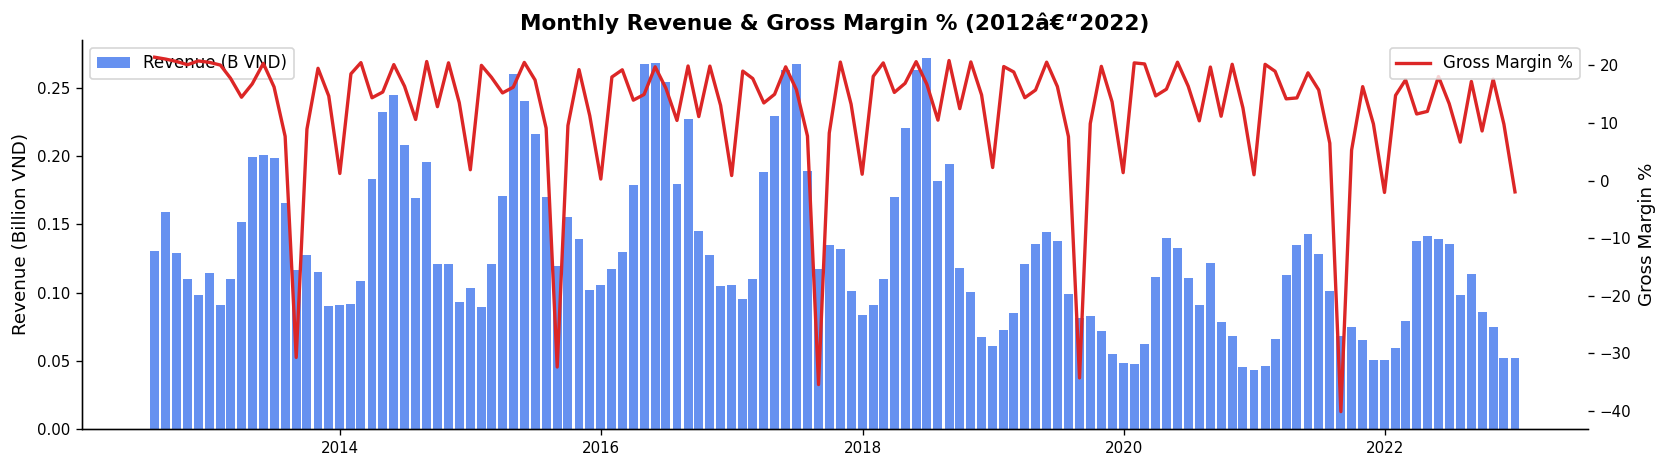

In [80]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart A1: Monthly revenue line chart ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
monthly_rev = sales.resample('ME', on='Date')[['Revenue', 'COGS']].sum()
monthly_rev['Margin%'] = (monthly_rev['Revenue'] - monthly_rev['COGS']) / monthly_rev['Revenue'] * 100

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly_rev.index, monthly_rev['Revenue'] / 1e9, width=25,
        color=PALETTE[0], alpha=0.7, label='Revenue (B VND)')
ax2.plot(monthly_rev.index, monthly_rev['Margin%'], color=PALETTE[2],
         lw=2, label='Gross Margin %')
ax1.set_title('Monthly Revenue & Gross Margin % (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

           Revenue          COGS   GrossProfit  Margin%  YoY_Rev%
Date                                                             
2012  7.414977e+08  5.874619e+08  1.540358e+08    20.77       NaN
2013  1.657169e+09  1.465980e+09  1.911893e+08    11.54    123.49
2014  1.871846e+09  1.574607e+09  2.972384e+08    15.88     12.95
2015  1.889934e+09  1.665442e+09  2.244920e+08    11.88      0.97
2016  2.104641e+09  1.780559e+09  3.240813e+08    15.40     11.36
2017  1.911164e+09  1.694386e+09  2.167785e+08    11.34     -9.19
2018  1.850122e+09  1.542176e+09  3.079467e+08    16.64     -3.19
2019  1.136801e+09  1.005203e+09  1.315986e+08    11.58    -38.56
2020  1.054512e+09  8.860851e+08  1.684271e+08    15.97     -7.24
2021  1.043040e+09  9.411301e+08  1.019097e+08     9.77     -1.09
2022  1.169749e+09  1.020420e+09  1.493287e+08    12.77     12.15


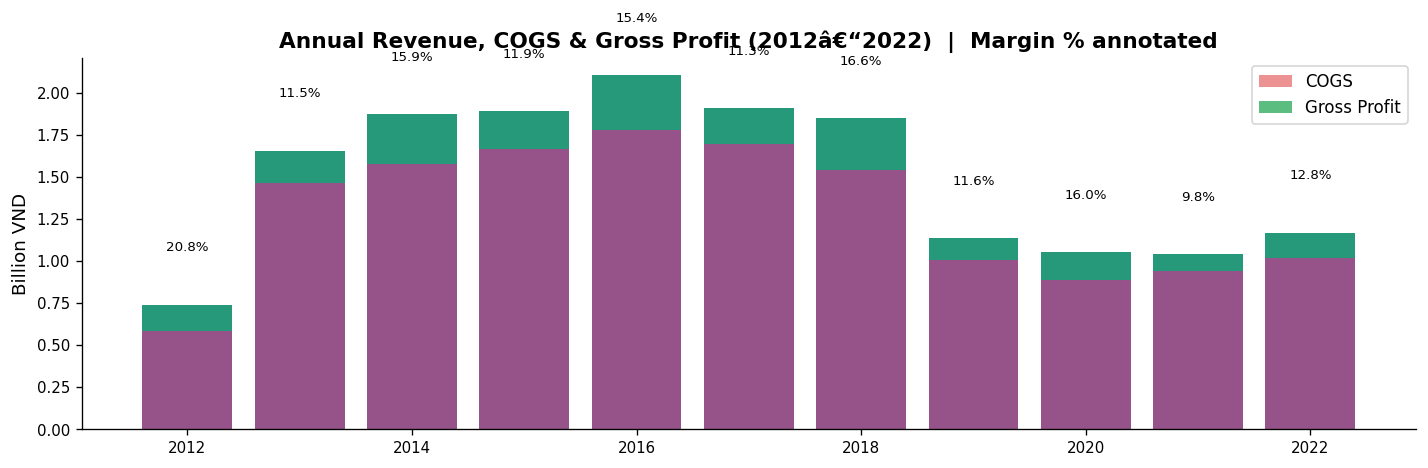

In [81]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart A2: Annual revenue bar chart ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
annual_rev = sales.resample('YE', on='Date')[['Revenue', 'COGS']].sum()
annual_rev.index = annual_rev.index.year
annual_rev['GrossProfit'] = annual_rev['Revenue'] - annual_rev['COGS']
annual_rev['Margin%'] = annual_rev['GrossProfit'] / annual_rev['Revenue'] * 100

# YoY growth
annual_rev['YoY_Rev%'] = annual_rev['Revenue'].pct_change() * 100
print(annual_rev[['Revenue','COGS','GrossProfit','Margin%','YoY_Rev%']].round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 4))
x = annual_rev.index
bars = ax.bar(x, annual_rev['Revenue'] / 1e9, color=PALETTE[0], alpha=0.8)
ax.bar(x, annual_rev['COGS'] / 1e9, color=PALETTE[2], alpha=0.5, label='COGS')
ax.bar(x, annual_rev['GrossProfit'] / 1e9, bottom=annual_rev['COGS'] / 1e9,
       color=PALETTE[1], alpha=0.7, label='Gross Profit')
for i, (yr, row) in enumerate(annual_rev.iterrows()):
    ax.text(yr, row['Revenue'] / 1e9 + 0.3, f"{row['Margin%']:.1f}%",
            ha='center', va='bottom', fontsize=8, color='black')
ax.set_title('Annual Revenue, COGS & Gross Profit (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)  |  Margin % annotated')
ax.set_ylabel('Billion VND')
ax.legend()
plt.tight_layout()
plt.show()

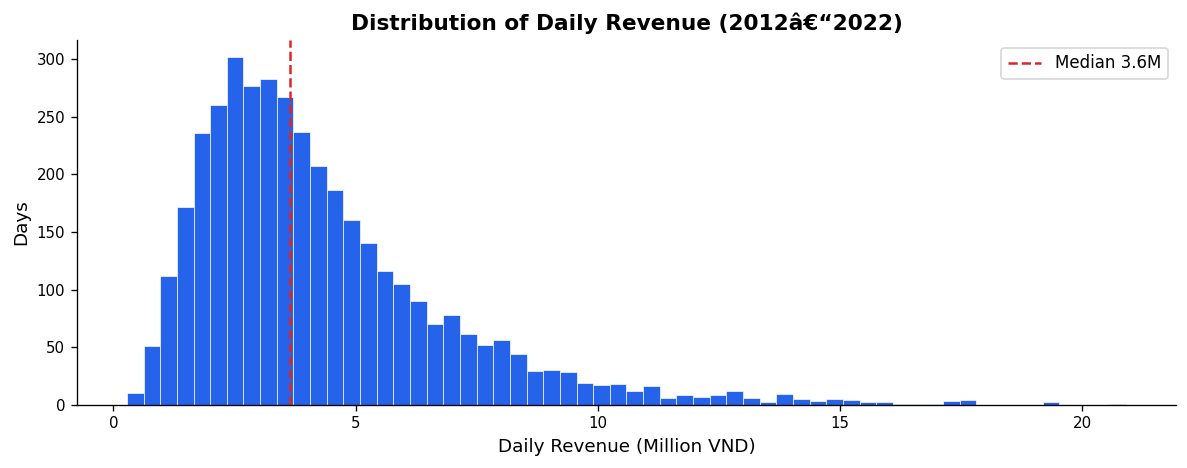

In [82]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart A3: Daily revenue histogram ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(sales['Revenue'] / 1e6, bins=60, color=PALETTE[0], edgecolor='white', linewidth=0.4)
ax.set_title('Distribution of Daily Revenue (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax.set_xlabel('Daily Revenue (Million VND)')
ax.set_ylabel('Days')
ax.axvline(sales['Revenue'].median() / 1e6, color=PALETTE[2], linestyle='--',
           label=f'Median {sales["Revenue"].median()/1e6:.1f}M')
ax.legend()
plt.tight_layout()
plt.show()

### B. Customers

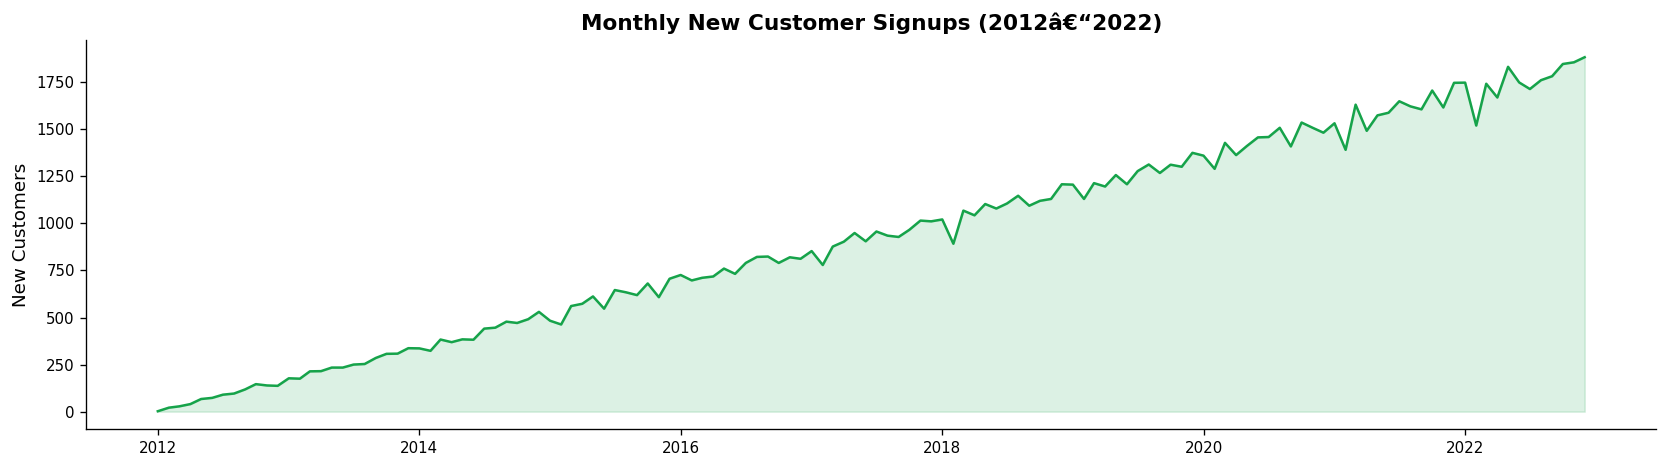

Total customers: 121,930


In [83]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart B1: Monthly new customers ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
customers['signup_month'] = customers['signup_date'].dt.to_period('M').dt.to_timestamp()
new_cust = customers.groupby('signup_month').size().rename('new_customers')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(new_cust.index, new_cust.values, color=PALETTE[1], lw=1.5)
ax.fill_between(new_cust.index, new_cust.values, alpha=0.15, color=PALETTE[1])
ax.set_title('Monthly New Customer Signups (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax.set_ylabel('New Customers')
ax.set_xlabel('')
plt.tight_layout()
plt.show()
print(f'Total customers: {len(customers):,}')

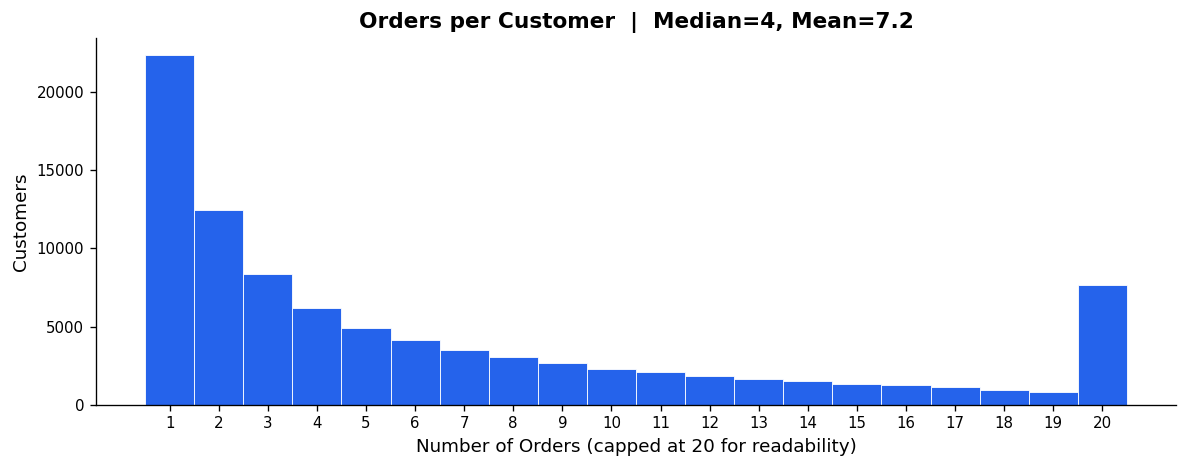

One-time buyers: 24.8%
Repeat (ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â°Ãƒâ€šÃ‚Â¥2 orders): 75.2%


In [84]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart B2: Orders per customer histogram ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
orders_per_cust = orders.groupby('customer_id')['order_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
vals = orders_per_cust.clip(upper=20)
ax.hist(vals, bins=range(1, 22), color=PALETTE[0], edgecolor='white', linewidth=0.5,
        align='left')
ax.set_title(f'Orders per Customer  |  Median={orders_per_cust.median():.0f}, '
             f'Mean={orders_per_cust.mean():.1f}')
ax.set_xlabel('Number of Orders (capped at 20 for readability)')
ax.set_ylabel('Customers')
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

one_time = (orders_per_cust == 1).mean() * 100
print(f'One-time buyers: {one_time:.1f}%')
print(f'Repeat (ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â°Ãƒâ€šÃ‚Â¥2 orders): {100 - one_time:.1f}%')

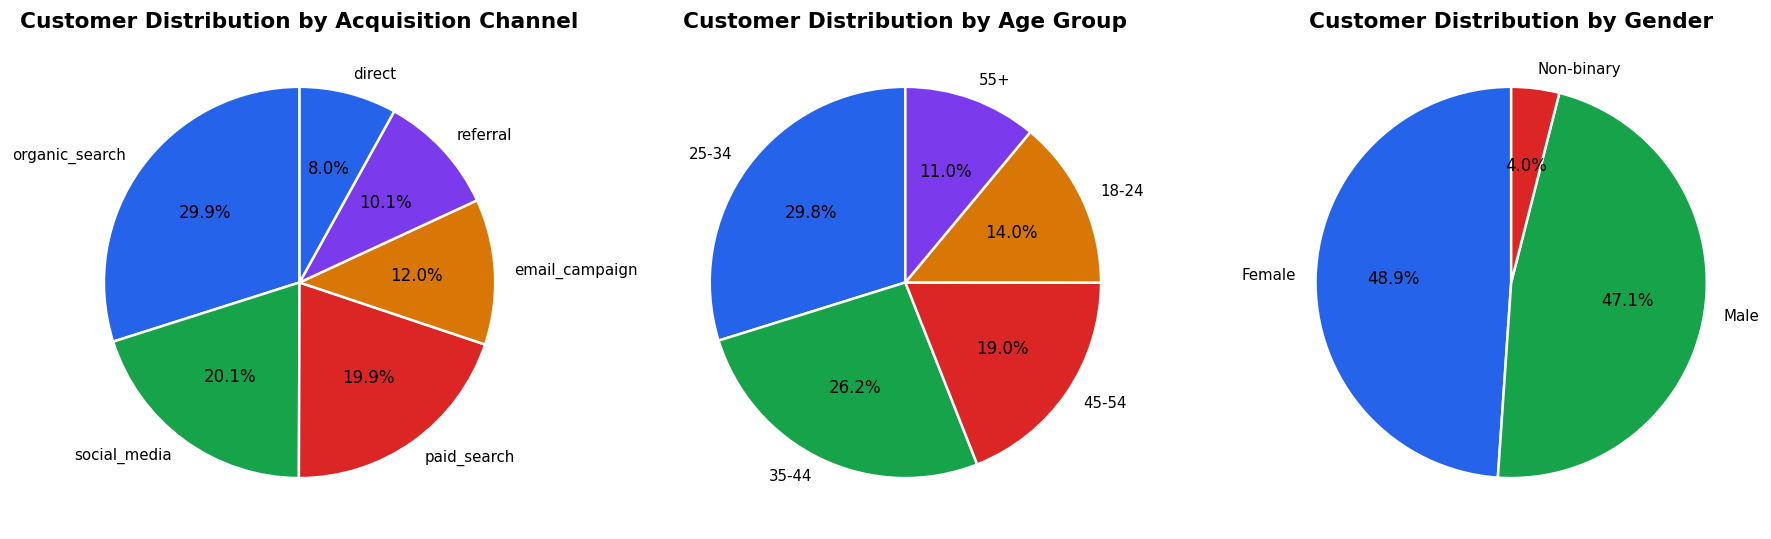

In [85]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart B3: Acquisition channel / Age group / Gender pies ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ['acquisition_channel', 'age_group', 'gender'],
    ['Acquisition Channel', 'Age Group', 'Gender'],
):
    counts = customers[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=PALETTE[:len(counts)], startangle=90,
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(f'Customer Distribution by {title}')

plt.tight_layout()
plt.show()

### C. Products

In [86]:
# Enrich order_items with product info and revenue
oi_rich = order_items.merge(products[['product_id','product_name','category','segment','price','cogs']],
                            on='product_id', how='left')
oi_rich['line_revenue'] = oi_rich['quantity'] * oi_rich['unit_price'] - oi_rich['discount_amount']
oi_rich['line_profit']  = oi_rich['line_revenue'] - oi_rich['quantity'] * oi_rich['cogs']

print('order_items enriched shape:', oi_rich.shape)

order_items enriched shape: (714669, 14)


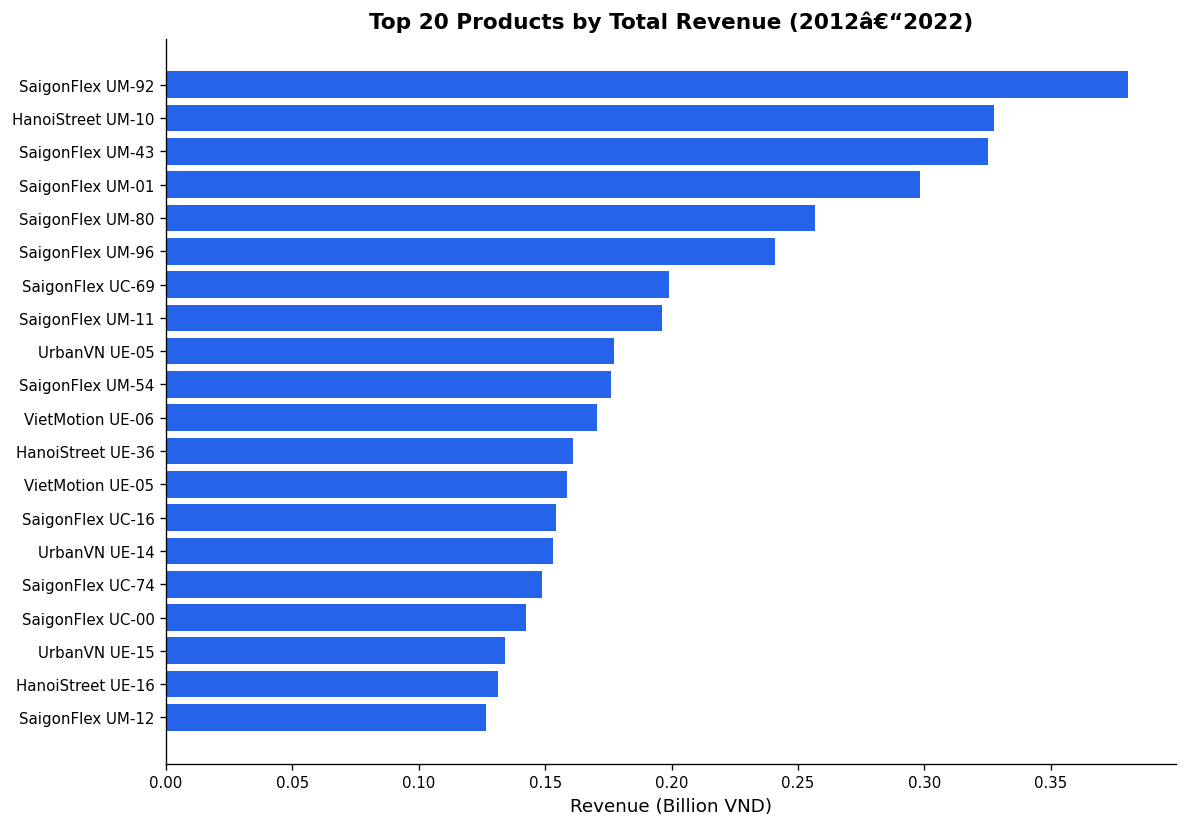

In [87]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C1: Top 20 products by revenue ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
top_products = (
    oi_rich.groupby('product_name')['line_revenue']
    .sum().nlargest(20).sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_products.index, top_products.values / 1e9, color=PALETTE[0])
ax.set_title('Top 20 Products by Total Revenue (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax.set_xlabel('Revenue (Billion VND)')
plt.tight_layout()
plt.show()

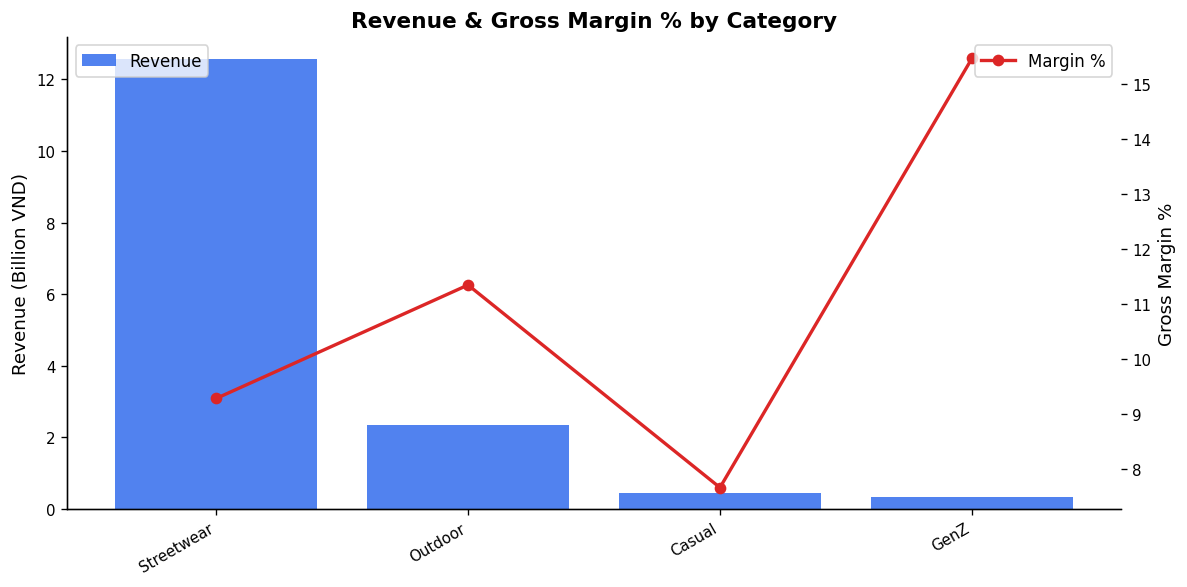

                 revenue        profit  margin
category                                      
Streetwear  1.255848e+10  1.165808e+09    9.28
Outdoor     2.353397e+09  2.670341e+08   11.35
Casual      4.402852e+08  3.374077e+07    7.66
GenZ        3.287102e+08  5.083638e+07   15.47


In [88]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C2: Revenue & Margin by category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
cat_stats = (
    oi_rich.groupby('category')
    .agg(revenue=('line_revenue', 'sum'), profit=('line_profit', 'sum'))
    .assign(margin=lambda x: x['profit'] / x['revenue'] * 100)
    .sort_values('revenue', ascending=False)
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x = range(len(cat_stats))
ax1.bar(x, cat_stats['revenue'] / 1e9, color=PALETTE[0], alpha=0.8, label='Revenue')
ax2.plot(x, cat_stats['margin'], 'o-', color=PALETTE[2], lw=2, label='Margin %')
ax1.set_xticks(list(x))
ax1.set_xticklabels(cat_stats.index, rotation=30, ha='right')
ax1.set_title('Revenue & Gross Margin % by Category')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()
print(cat_stats.round(2).to_string())

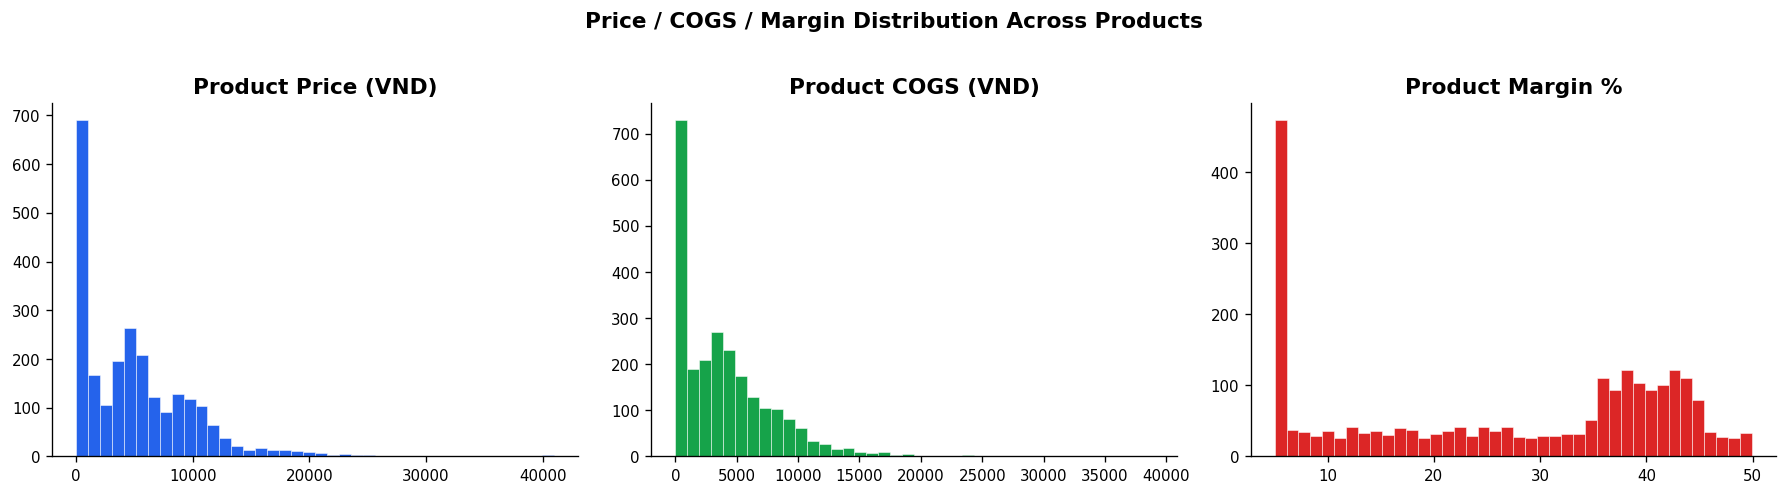

In [89]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C3: Price, COGS, Margin distributions ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
    axes,
    ['price', 'cogs', 'margin_pct'],
    ['Product Price (VND)', 'Product COGS (VND)', 'Product Margin %'],
    PALETTE[:3],
):
    axes[list(axes).index(ax)].hist(products[col], bins=40, color=color, edgecolor='white', lw=0.3)
    ax.set_title(title)

plt.suptitle('Price / COGS / Margin Distribution Across Products', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### C4. Revenue & Gross Margin % by Category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Yearly Trends

In [90]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Data prep: join order year onto oi_rich ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
oi_year = oi_rich.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
oi_year['year'] = oi_year['order_date'].dt.year

cat_year = (
    oi_year
    .groupby(['year', 'category'], as_index=False)
    .agg(revenue=('line_revenue', 'sum'), profit=('line_profit', 'sum'))
)
cat_year['margin'] = cat_year['profit'] / cat_year['revenue'] * 100
print(cat_year.dtypes)
print(cat_year.head(8))

year          int32
category     object
revenue     float64
profit      float64
margin      float64
dtype: object
   year    category       revenue        profit     margin
0  2012      Casual  1.172854e+07  2.174001e+06  18.535996
1  2012        GenZ  9.510543e+06  2.136865e+06  22.468381
2  2012     Outdoor  1.621721e+08  3.507859e+07  21.630471
3  2012  Streetwear  5.580865e+08  1.146464e+08  20.542757
4  2013      Casual  2.778138e+07  3.054813e+06  10.995903
5  2013        GenZ  2.557689e+07  3.599908e+06  14.074846
6  2013     Outdoor  3.059345e+08  2.565742e+07   8.386571
7  2013  Streetwear  1.210872e+09  7.187293e+07   5.935632


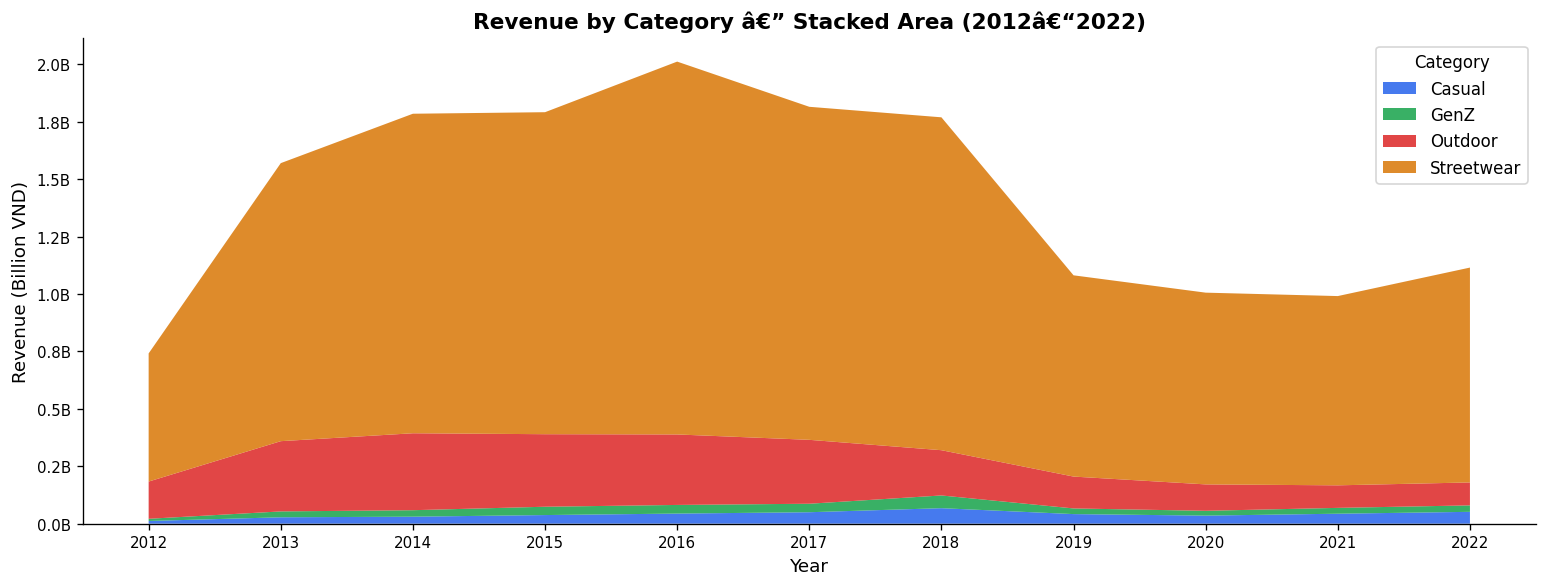

In [91]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C4a: Stacked Area ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Revenue by category per year ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
rev_pivot = cat_year.pivot(index='year', columns='category', values='revenue').fillna(0) / 1e9
categories = rev_pivot.columns.tolist()
cat_colors = PALETTE[:len(categories)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(rev_pivot.index, [rev_pivot[c] for c in categories],
             labels=categories, colors=cat_colors, alpha=0.85)
ax.set_title('Revenue by Category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Stacked Area (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax.set_ylabel('Revenue (Billion VND)')
ax.set_xlabel('Year')
ax.set_xticks(rev_pivot.index)
ax.legend(loc='upper right', title='Category')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))
plt.tight_layout()
plt.show()

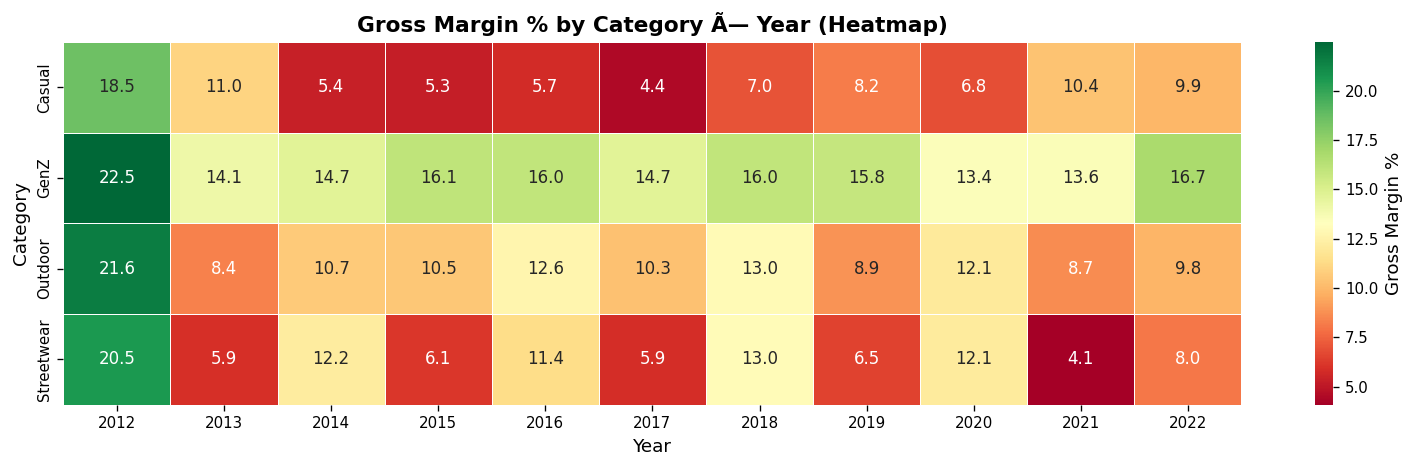

In [92]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C4b: Heatmap ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Gross Margin % by category ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â year ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
margin_pivot = cat_year.pivot(index='category', columns='year', values='margin')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    margin_pivot,
    annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Gross Margin %'},
    ax=ax,
)
ax.set_title('Gross Margin % by Category ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â Year (Heatmap)')
ax.set_xlabel('Year')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

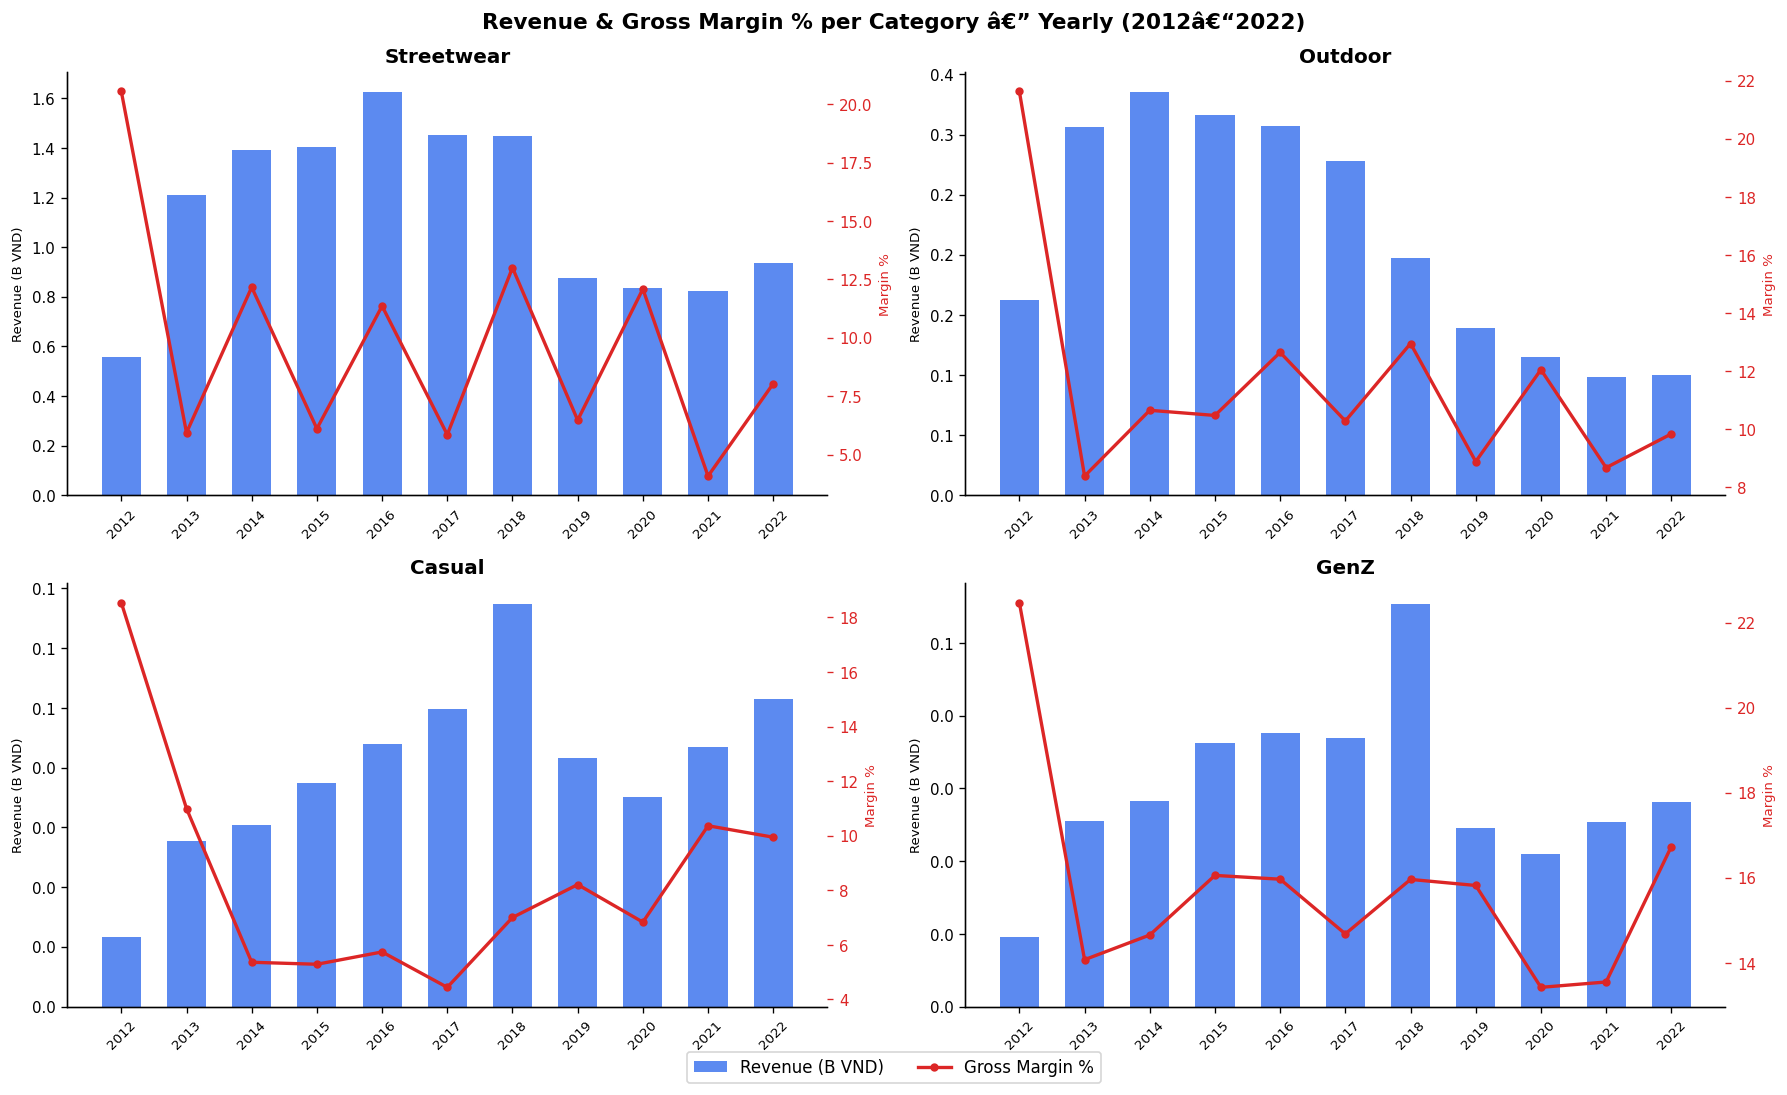

In [93]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart C4c: Small Multiples ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Revenue (bar) + Margin % (line) per category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
cat_totals = (
    cat_year.groupby('category', as_index=False)['revenue']
    .sum()
    .sort_values('revenue', ascending=False)
)
categories_sorted = cat_totals['category'].tolist()
years = sorted(cat_year['year'].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))  # no sharex ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â conflicts with twinx
axes = axes.flatten()

for ax, cat in zip(axes, categories_sorted):
    df_cat = cat_year[cat_year['category'] == cat].set_index('year').reindex(years)
    ax2 = ax.twinx()

    bars = ax.bar(years, df_cat['revenue'] / 1e9, color=PALETTE[0], alpha=0.75, width=0.6)
    line, = ax2.plot(years, df_cat['margin'], color=PALETTE[2], lw=2, marker='o', ms=4)

    ax.set_title(cat, fontsize=12, fontweight='bold')
    ax.set_ylabel('Revenue (B VND)', fontsize=8)
    ax2.set_ylabel('Margin %', fontsize=8, color=PALETTE[2])
    ax2.tick_params(axis='y', colors=PALETTE[2])
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))

fig.suptitle('Revenue & Gross Margin % per Category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Yearly (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)',
             fontsize=13, fontweight='bold')
fig.legend([bars, line], ['Revenue (B VND)', 'Gross Margin %'],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

### D. Promotions

D1 checks:
  Valid campaigns: 50
  Month range: 2012-07 -> 2022-12
  Months with active promo: 105
  Peak active campaigns: 2
  Revenue unit: Million VND (rounded integer)
Saved: C:\Users\Admin\Downloads\Vin Datathon\figures\D1a_promo_band_revenue.png


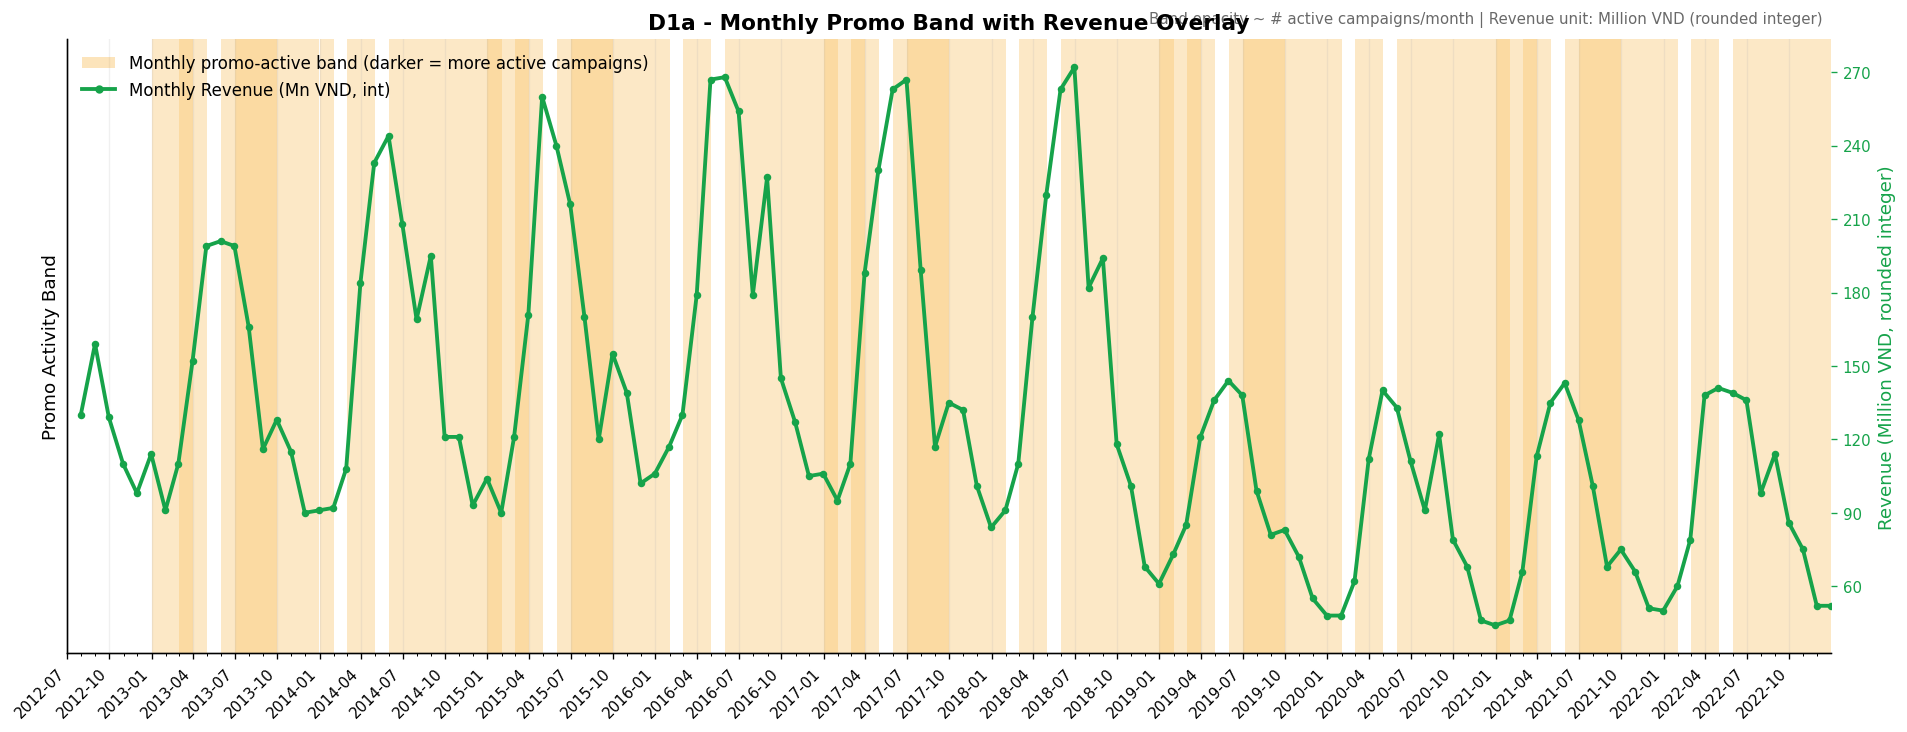

Saved: C:\Users\Admin\Downloads\Vin Datathon\figures\D1b_promo_band_margin.png


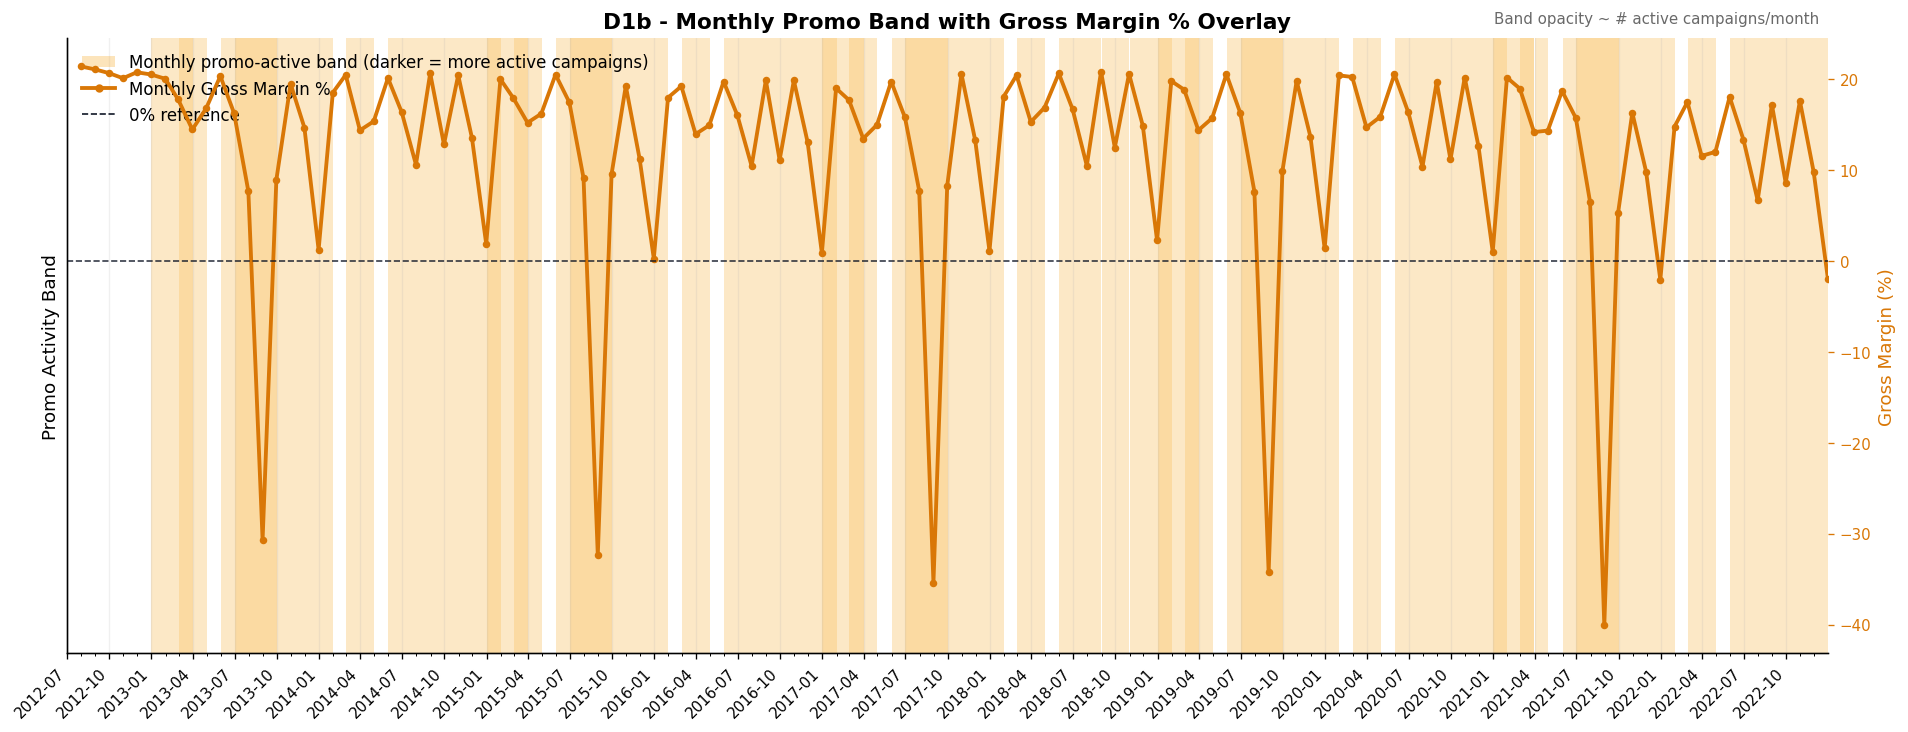


Promo-month preview:
month_start  active_campaigns  active_percentage  active_fixed
 2012-07-01                 0                  0             0
 2012-08-01                 0                  0             0
 2012-09-01                 0                  0             0
 2012-10-01                 0                  0             0
 2012-11-01                 0                  0             0
 2012-12-01                 0                  0             0
 2013-01-01                 1                  1             0
 2013-02-01                 1                  1             0
 2013-03-01                 2                  2             0
 2013-04-01                 1                  1             0
 2013-05-01                 0                  0             0
 2013-06-01                 1                  1             0


In [145]:
# ---- D1 FINAL: Monthly promo band + Revenue/Margin overlays (self-contained) ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

if 'PALETTE' not in globals():
    PALETTE = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']

data_dir = Path('./data')

if 'promotions' not in globals():
    promo_path = data_dir / 'promotions.csv'
    if not promo_path.exists():
        raise FileNotFoundError(f"Missing file: {promo_path.resolve()}")
    promotions = pd.read_csv(promo_path)

if 'sales' not in globals():
    sales_path = data_dir / 'sales.csv'
    if not sales_path.exists():
        raise FileNotFoundError(f"Missing file: {sales_path.resolve()}")
    sales = pd.read_csv(sales_path)

promo = promotions.copy()
for c in ['start_date', 'end_date']:
    promo[c] = pd.to_datetime(promo[c], errors='coerce')

invalid_mask = promo['start_date'].isna() | promo['end_date'].isna() | (promo['end_date'] < promo['start_date'])
invalid_count = int(invalid_mask.sum())
if invalid_count > 0:
    print(f"[WARN] Dropping {invalid_count} invalid promotion rows.")

promo = promo.loc[~invalid_mask].copy()
if promo.empty:
    raise ValueError('No valid promotions available after validation.')

promo['_promo_type_norm'] = promo.get('promo_type', pd.Series(['unknown'] * len(promo), index=promo.index)).astype(str).str.lower().str.strip()

if 'Date' not in sales.columns or 'Revenue' not in sales.columns or 'COGS' not in sales.columns:
    raise ValueError("sales data must contain Date, Revenue, COGS")

monthly_sales = (
    sales.copy()
    .assign(Date=lambda df: pd.to_datetime(df['Date'], errors='coerce'))
    .dropna(subset=['Date'])
    .set_index('Date')
    .resample('ME')[['Revenue', 'COGS']]
    .sum()
)
if monthly_sales.empty:
    raise ValueError('No monthly sales data available for overlay.')

# Revenue shown as rounded integer with auto-scaled unit for clear visibility
if monthly_sales['Revenue'].max() >= 1e9:
    revenue_divisor = 1e9
    revenue_unit_label = 'Billion VND'
    revenue_unit_short = 'Bn VND'
elif monthly_sales['Revenue'].max() >= 1e6:
    revenue_divisor = 1e6
    revenue_unit_label = 'Million VND'
    revenue_unit_short = 'Mn VND'
elif monthly_sales['Revenue'].max() >= 1e3:
    revenue_divisor = 1e3
    revenue_unit_label = 'Thousand VND'
    revenue_unit_short = 'K VND'
else:
    revenue_divisor = 1
    revenue_unit_label = 'VND'
    revenue_unit_short = 'VND'

monthly_sales['Revenue_Display_Int'] = (monthly_sales['Revenue'] / revenue_divisor).round().astype(int)
monthly_sales['GrossMarginPct'] = np.where(
    monthly_sales['Revenue'] != 0,
    (monthly_sales['Revenue'] - monthly_sales['COGS']) / monthly_sales['Revenue'] * 100,
    np.nan,
)

promo_start_month = promo['start_date'].min().to_period('M').to_timestamp()
promo_end_month = promo['end_date'].max().to_period('M').to_timestamp()
sales_start_month = monthly_sales.index.min().to_period('M').to_timestamp()
sales_end_month = monthly_sales.index.max().to_period('M').to_timestamp()

x_min = min(promo_start_month, sales_start_month)
x_max = max(promo_end_month, sales_end_month) + pd.offsets.MonthEnd(1)

months = pd.date_range(x_min, x_max, freq='MS')
promo_month = pd.DataFrame({'month_start': months})
promo_month['month_end'] = promo_month['month_start'] + pd.offsets.MonthEnd(1)

promo_month['active_campaigns'] = [
    int(((promo['start_date'] <= me) & (promo['end_date'] >= ms)).sum())
    for ms, me in zip(promo_month['month_start'], promo_month['month_end'])
]
promo_month['active_percentage'] = [
    int(((promo['start_date'] <= me) & (promo['end_date'] >= ms) & (promo['_promo_type_norm'] == 'percentage')).sum())
    for ms, me in zip(promo_month['month_start'], promo_month['month_end'])
]
promo_month['active_fixed'] = [
    int(((promo['start_date'] <= me) & (promo['end_date'] >= ms) & (promo['_promo_type_norm'] != 'percentage')).sum())
    for ms, me in zip(promo_month['month_start'], promo_month['month_end'])
]
promo_month['promo_active_flag'] = promo_month['active_campaigns'] > 0

max_active = max(1, int(promo_month['active_campaigns'].max()))

print('D1 checks:')
print(f"  Valid campaigns: {len(promo)}")
print(f"  Month range: {promo_month['month_start'].min():%Y-%m} -> {promo_month['month_start'].max():%Y-%m}")
print(f"  Months with active promo: {int(promo_month['promo_active_flag'].sum())}")
print(f"  Peak active campaigns: {max_active}")
print(f"  Revenue unit: {revenue_unit_label} (rounded integer)")


def _format_time_axis(ax):
    ax.set_xlim(x_min, x_max)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
    ax.grid(axis='x', which='major', alpha=0.18)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


def _draw_promo_band(ax, df):
    for _, row in df.iterrows():
        if row['active_campaigns'] <= 0:
            continue
        alpha = 0.08 + 0.30 * (row['active_campaigns'] / max_active)
        ax.axvspan(row['month_start'], row['month_end'] + pd.Timedelta(hours=23), color='#f59e0b', alpha=float(alpha), lw=0)


# Save to figures folder with same naming style as existing files
chart_dir = Path('./figures')
chart_dir.mkdir(parents=True, exist_ok=True)

# D1a: Promo band + Revenue (integer, no area fill)
fig, ax = plt.subplots(figsize=(16, 6.2))
_draw_promo_band(ax, promo_month)
ax2 = ax.twinx()
ax2.plot(monthly_sales.index, monthly_sales['Revenue_Display_Int'], color=PALETTE[1], linewidth=2.3, marker='o', markersize=3.5)
ax2.set_ylabel(f'Revenue ({revenue_unit_label}, rounded integer)', color=PALETTE[1])
ax2.tick_params(axis='y', colors=PALETTE[1])
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

_format_time_axis(ax)
ax.set_ylabel('Promo Activity Band')
ax.set_yticks([])
ax.set_title('D1a - Monthly Promo Band with Revenue Overlay')
ax.text(
    0.995,
    1.02,
    f'Band opacity ~ # active campaigns/month | Revenue unit: {revenue_unit_label} (rounded integer)',
    transform=ax.transAxes,
    ha='right',
    va='bottom',
    fontsize=9,
    color='dimgray'
)
ax.legend(handles=[
    Patch(facecolor='#f59e0b', alpha=0.28, label='Monthly promo-active band (darker = more active campaigns)'),
    Line2D([0], [0], color=PALETTE[1], lw=2.3, marker='o', ms=4, label=f'Monthly Revenue ({revenue_unit_short}, int)'),
], loc='upper left', frameon=False)

plt.tight_layout()
out_revenue = chart_dir / 'D1a_promo_band_revenue.png'
fig.savefig(out_revenue, dpi=220, bbox_inches='tight')
print(f"Saved: {out_revenue.resolve()}")
plt.show()

# D1b: Promo band + Margin
fig, ax = plt.subplots(figsize=(16, 6.2))
_draw_promo_band(ax, promo_month)
ax2 = ax.twinx()
ax2.plot(monthly_sales.index, monthly_sales['GrossMarginPct'], color=PALETTE[3], linewidth=2.3, marker='o', markersize=3.5)
ax2.axhline(0, color='#111827', linestyle='--', linewidth=1.0, alpha=0.85)
ax2.set_ylabel('Gross Margin (%)', color=PALETTE[3])
ax2.tick_params(axis='y', colors=PALETTE[3])

_format_time_axis(ax)
ax.set_ylabel('Promo Activity Band')
ax.set_yticks([])
ax.set_title('D1b - Monthly Promo Band with Gross Margin % Overlay')
ax.text(0.995, 1.02, 'Band opacity ~ # active campaigns/month', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color='dimgray')
ax.legend(handles=[
    Patch(facecolor='#f59e0b', alpha=0.28, label='Monthly promo-active band (darker = more active campaigns)'),
    Line2D([0], [0], color=PALETTE[3], lw=2.3, marker='o', ms=4, label='Monthly Gross Margin %'),
    Line2D([0], [0], color='#111827', lw=1.0, linestyle='--', label='0% reference'),
], loc='upper left', frameon=False)

plt.tight_layout()
out_margin = chart_dir / 'D1b_promo_band_margin.png'
fig.savefig(out_margin, dpi=220, bbox_inches='tight')
print(f"Saved: {out_margin.resolve()}")
plt.show()

print('\nPromo-month preview:')
print(promo_month[['month_start', 'active_campaigns', 'active_percentage', 'active_fixed']].head(12).to_string(index=False))


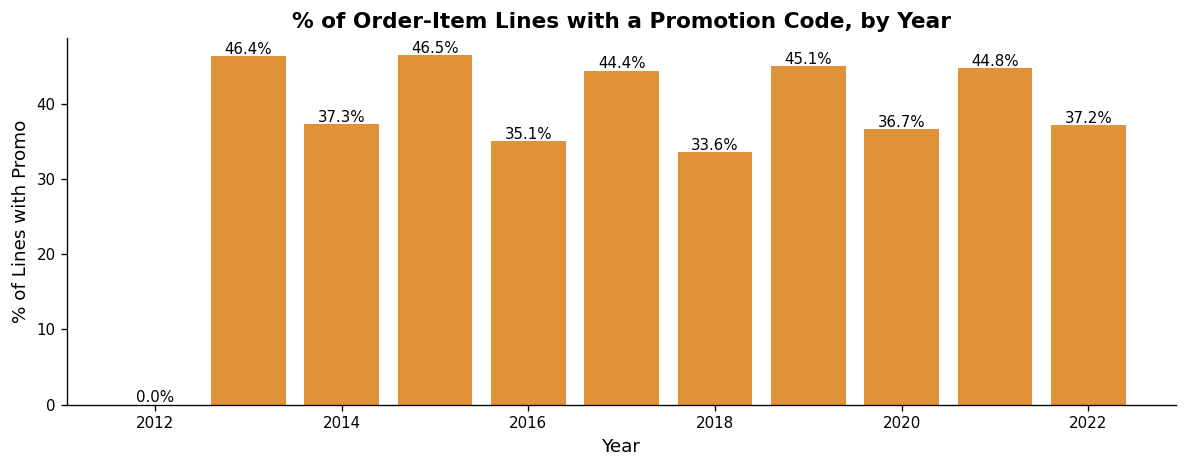

In [146]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart D2: % order-item lines with a promo by year ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
orders_dated = orders[['order_id','order_date']].copy()
oi_dated = order_items.merge(orders_dated, on='order_id', how='left')
oi_dated['year'] = oi_dated['order_date'].dt.year
oi_dated['has_promo'] = oi_dated['promo_id'].notna()

promo_by_year = oi_dated.groupby('year')['has_promo'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(promo_by_year.index, promo_by_year.values, color=PALETTE[3], alpha=0.8)
ax.set_title('% of Order-Item Lines with a Promotion Code, by Year')
ax.set_ylabel('% of Lines with Promo')
ax.set_xlabel('Year')
for yr, val in promo_by_year.items():
    ax.text(yr, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### E. Operations

In [147]:
# Enrich orders with geography
orders_geo = orders.merge(geography[['zip','region']], on='zip', how='left')

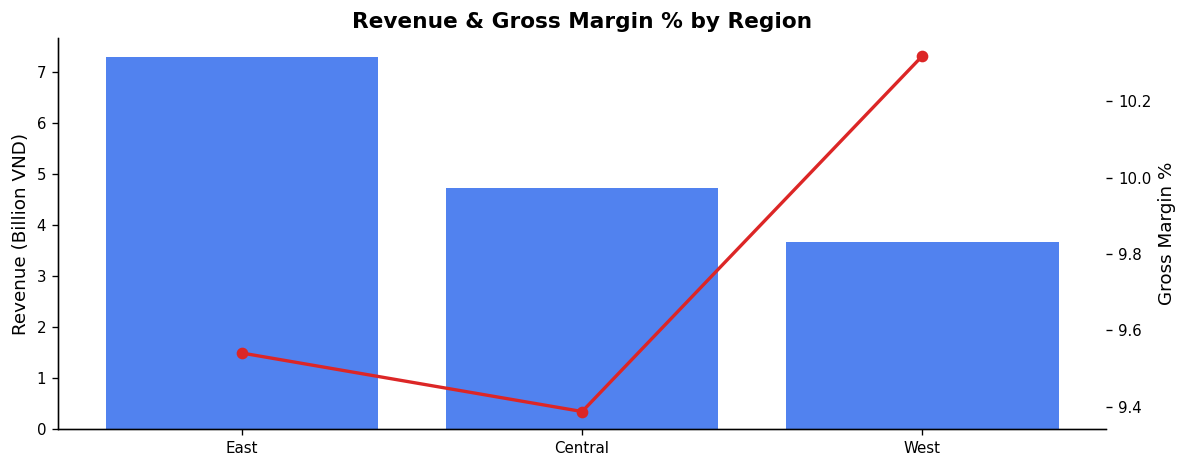

              revenue        profit  margin
region                                     
East     7.291151e+09  6.956483e+08    9.54
Central  4.719491e+09  4.430609e+08    9.39
West     3.670227e+09  3.787095e+08   10.32


In [148]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart E1: Revenue by region ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
# Approximate: count orders per region, then scale by average order value
# Better: join to order_items revenue
oi_region = oi_rich.merge(orders[['order_id','zip']], on='order_id', how='left') \
                   .merge(geography[['zip','region']], on='zip', how='left')

region_rev = oi_region.groupby('region')['line_revenue'].sum().sort_values(ascending=False)
region_margin = oi_region.groupby('region').apply(
    lambda g: (g['line_revenue'].sum() - g['line_profit'].mul(-1).add(g['line_revenue']).sum())
    / g['line_revenue'].sum() * 100
)

# Simpler margin calc
region_stats = oi_region.groupby('region').agg(
    revenue=('line_revenue','sum'),
    profit=('line_profit','sum')
).assign(margin=lambda x: x['profit']/x['revenue']*100).sort_values('revenue', ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
x = range(len(region_stats))
ax1.bar(x, region_stats['revenue'] / 1e9, color=PALETTE[0], alpha=0.8)
ax2.plot(x, region_stats['margin'], 'o-', color=PALETTE[2], lw=2)
ax1.set_xticks(list(x))
ax1.set_xticklabels(region_stats.index)
ax1.set_title('Revenue & Gross Margin % by Region')
ax1.set_ylabel('Revenue (Billion VND)')
ax2.set_ylabel('Gross Margin %')
plt.tight_layout()
plt.show()
print(region_stats.round(2))

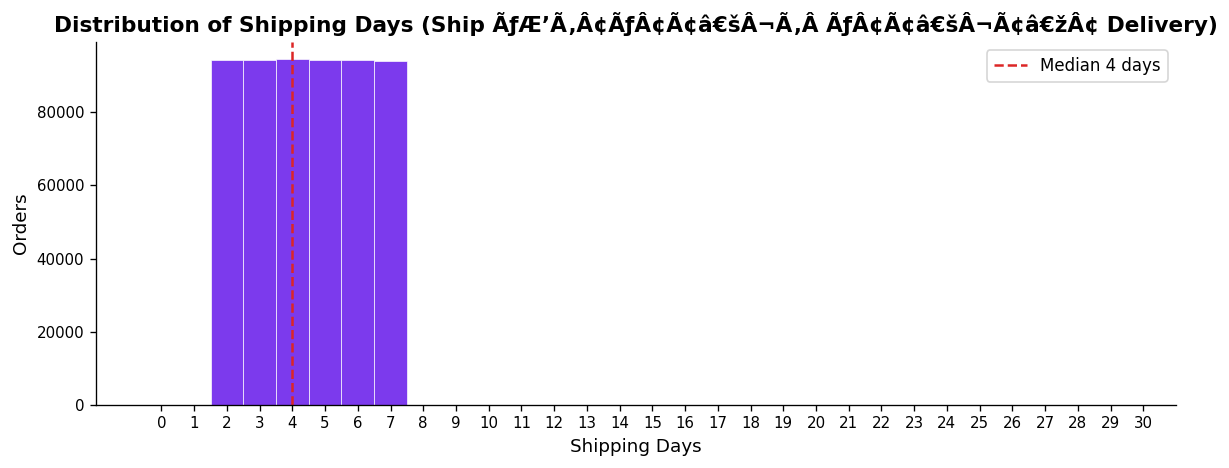

count    566067.00
mean          4.50
std           1.71
min           2.00
25%           3.00
50%           4.00
75%           6.00
max           7.00
Name: shipping_days, dtype: float64


In [149]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart E2: Shipping days distribution ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
shipments['shipping_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
valid_ship = shipments[shipments['shipping_days'].between(0, 30)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_ship['shipping_days'], bins=range(0, 31), color=PALETTE[4],
        edgecolor='white', lw=0.4, align='left')
ax.axvline(valid_ship['shipping_days'].median(), color=PALETTE[2],
           linestyle='--', label=f'Median {valid_ship["shipping_days"].median():.0f} days')
ax.set_title('Distribution of Shipping Days (Ship ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ Delivery)')
ax.set_xlabel('Shipping Days')
ax.set_ylabel('Orders')
ax.set_xticks(range(0, 31))
ax.legend()
plt.tight_layout()
plt.show()
print(valid_ship['shipping_days'].describe().round(2))

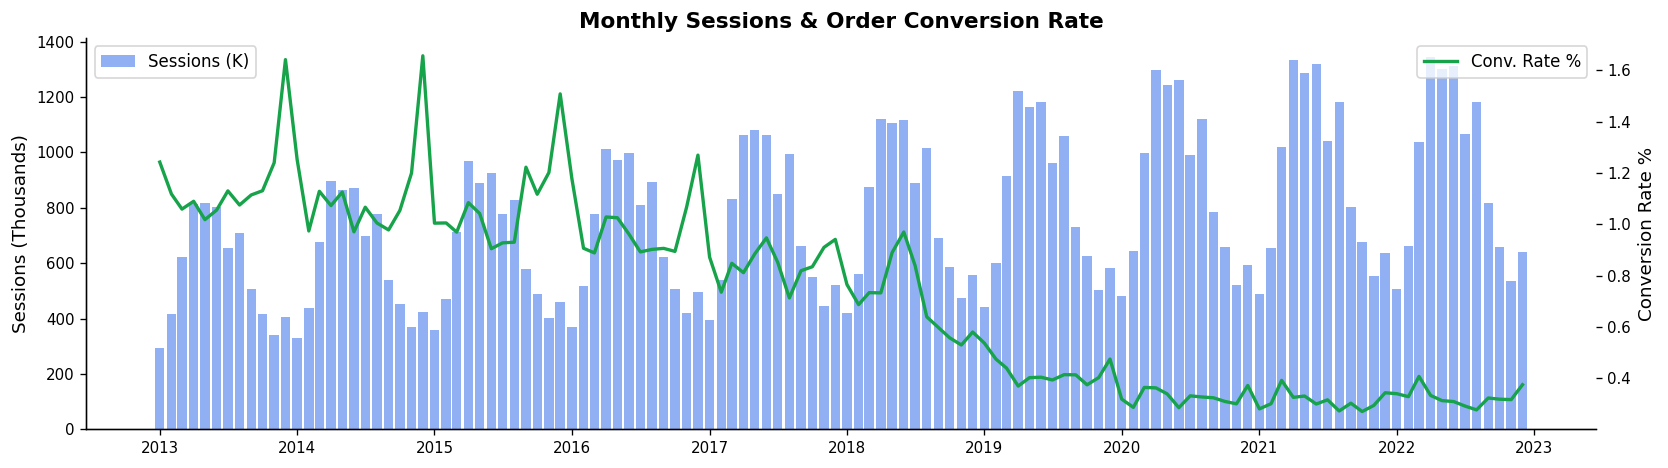

In [150]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart E3: Monthly conversion rate ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
web_traffic['month'] = web_traffic['date'].dt.to_period('M').dt.to_timestamp()
monthly_web = web_traffic.groupby('month').agg(
    sessions=('sessions', 'sum'),
    conversion_rate=('sessions', lambda x: None)  # placeholder
).drop(columns='conversion_rate')

# Compute conversion as orders/sessions
monthly_orders = orders.copy()
monthly_orders['month'] = monthly_orders['order_date'].dt.to_period('M').dt.to_timestamp()
orders_pm = monthly_orders.groupby('month')['order_id'].count().rename('orders')
monthly_web = monthly_web.join(orders_pm)
monthly_web['conv_rate'] = monthly_web['orders'] / monthly_web['sessions'] * 100

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly_web.index, monthly_web['sessions'] / 1e3, width=25,
        color=PALETTE[0], alpha=0.5, label='Sessions (K)')
ax2.plot(monthly_web.index, monthly_web['conv_rate'], color=PALETTE[1],
         lw=2, label='Conv. Rate %')
ax1.set_title('Monthly Sessions & Order Conversion Rate')
ax1.set_ylabel('Sessions (Thousands)')
ax2.set_ylabel('Conversion Rate %')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

### F. Quality & Customer Experience

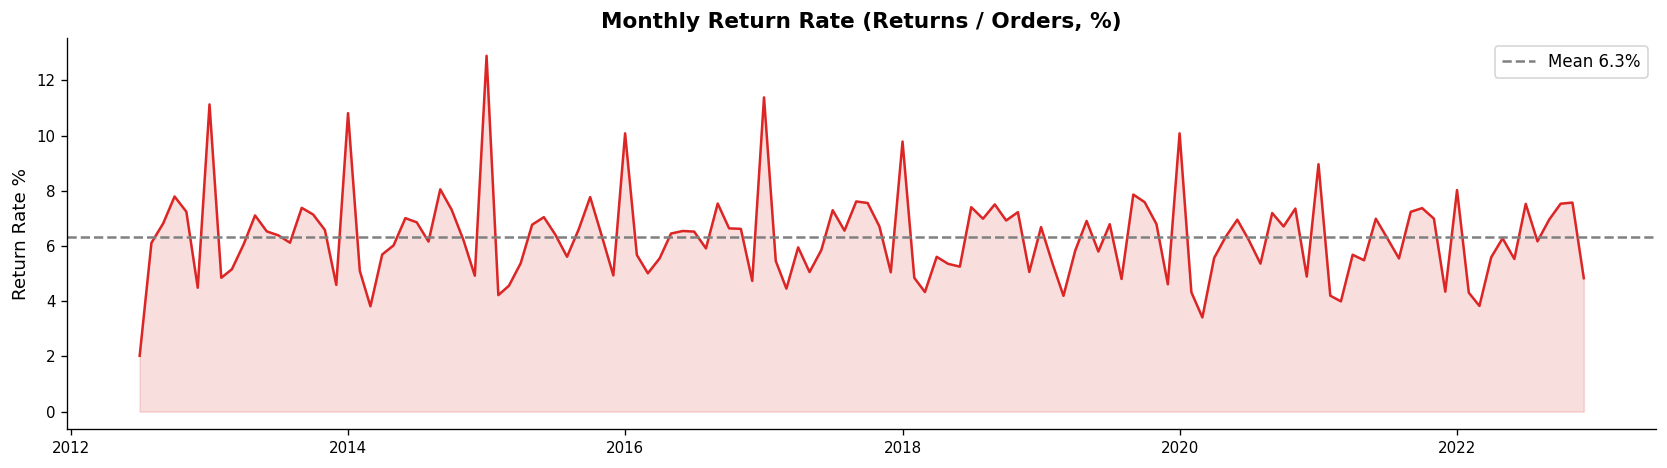

In [151]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart F1: Monthly return rate ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
returns['month'] = returns['return_date'].dt.to_period('M').dt.to_timestamp()
monthly_returns = returns.groupby('month')['return_id'].count().rename('returns')

orders_monthly = orders.copy()
orders_monthly['month'] = orders_monthly['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_orders_count = orders_monthly.groupby('month')['order_id'].count().rename('orders')

return_rate = (monthly_returns / monthly_orders_count * 100).dropna()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(return_rate.index, return_rate.values, color=PALETTE[2], lw=1.5)
ax.fill_between(return_rate.index, return_rate.values, alpha=0.15, color=PALETTE[2])
ax.set_title('Monthly Return Rate (Returns / Orders, %)')
ax.set_ylabel('Return Rate %')
ax.axhline(return_rate.mean(), linestyle='--', color='gray',
           label=f'Mean {return_rate.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

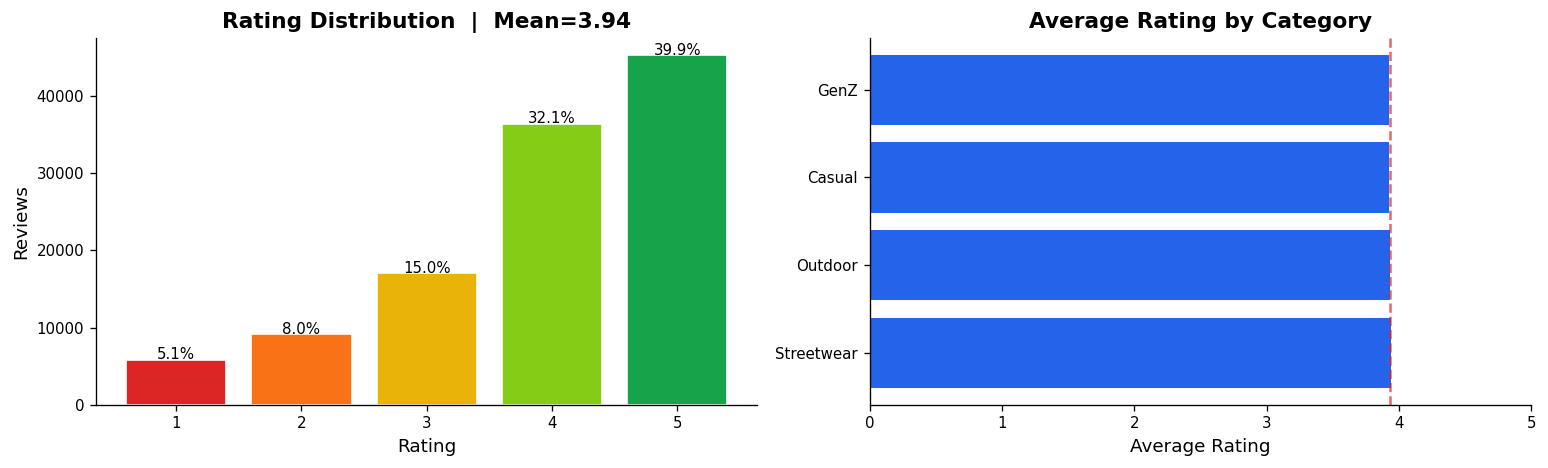

In [152]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart F2: Rating distribution ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
rating_counts = reviews['rating'].value_counts().sort_index()
colors_rating = ['#dc2626', '#f97316', '#eab308', '#84cc16', '#16a34a']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(rating_counts.index, rating_counts.values,
            color=colors_rating, edgecolor='white')
axes[0].set_title(f'Rating Distribution  |  Mean={reviews["rating"].mean():.2f}')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Reviews')
for r, c in zip(rating_counts.index, rating_counts.values):
    axes[0].text(r, c + 100, f'{c/len(reviews)*100:.1f}%', ha='center', fontsize=9)

# Rating by category
rev_cat = reviews.merge(order_items[['order_id','product_id']].drop_duplicates(),
                        on=['order_id','product_id'], how='left') \
                 .merge(products[['product_id','category']], on='product_id', how='left')
cat_rating = rev_cat.groupby('category')['rating'].mean().sort_values(ascending=False)
axes[1].barh(cat_rating.index, cat_rating.values, color=PALETTE[0])
axes[1].set_title('Average Rating by Category')
axes[1].set_xlabel('Average Rating')
axes[1].set_xlim(0, 5)
axes[1].axvline(reviews['rating'].mean(), color=PALETTE[2], linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

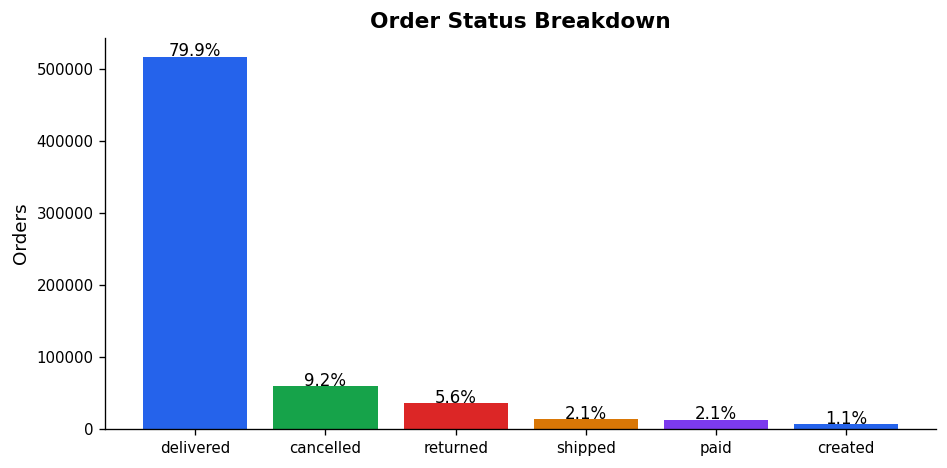

order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64


In [153]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart F3: Order status breakdown ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
status_counts = orders['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(status_counts.index, status_counts.values, color=PALETTE[:len(status_counts)])
ax.set_title('Order Status Breakdown')
ax.set_ylabel('Orders')
for bar, count in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count/len(orders)*100:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print(status_counts)

### G. Inventory
#### G1. Monthly Avg Stock-on-Hand vs Units Sold

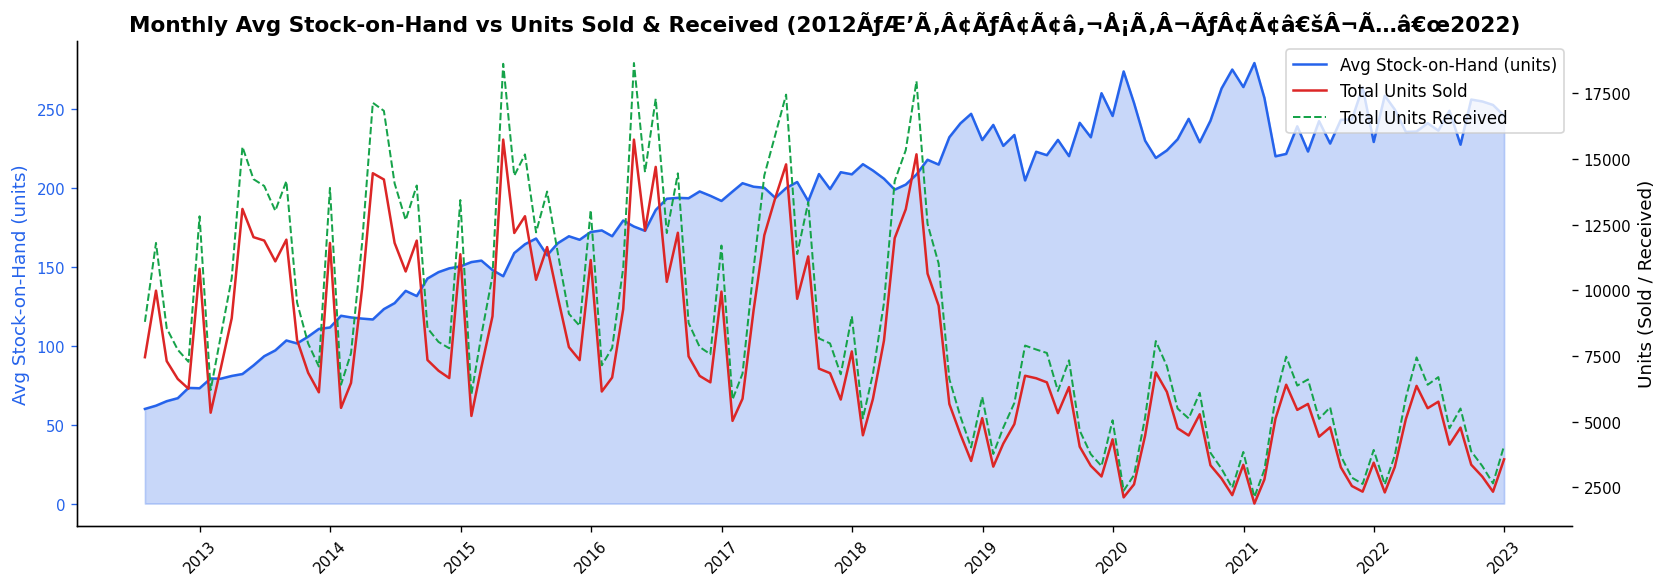

       avg_stock  total_sold  total_received
count      126.0       126.0           126.0
mean       189.4      7372.0          8629.1
std         57.3      3567.7          4260.8
min         60.0      1882.0          2129.0
25%        151.0      4753.2          5496.8
50%        202.6      6636.0          7738.0
75%        233.3     10255.8         12081.8
max        279.3     15731.0         18644.0


In [154]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Chart G1: Monthly avg Stock-on-Hand vs Units Sold (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022) ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
inv_monthly = (
    inventory
    .groupby('snapshot_date', as_index=False)
    .agg(
        avg_stock=('stock_on_hand', 'mean'),
        total_sold=('units_sold', 'sum'),
        total_received=('units_received', 'sum'),
    )
    .sort_values('snapshot_date')
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(inv_monthly['snapshot_date'], inv_monthly['avg_stock'],
                 alpha=0.25, color=PALETTE[0])
ax1.plot(inv_monthly['snapshot_date'], inv_monthly['avg_stock'],
         color=PALETTE[0], lw=1.5, label='Avg Stock-on-Hand (units)')

ax2.plot(inv_monthly['snapshot_date'], inv_monthly['total_sold'],
         color=PALETTE[2], lw=1.5, label='Total Units Sold')
ax2.plot(inv_monthly['snapshot_date'], inv_monthly['total_received'],
         color=PALETTE[1], lw=1.2, linestyle='--', label='Total Units Received')

ax1.set_title('Monthly Avg Stock-on-Hand vs Units Sold & Received (2012ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ2022)')
ax1.set_ylabel('Avg Stock-on-Hand (units)', color=PALETTE[0])
ax2.set_ylabel('Units (Sold / Received)', color='black')
ax1.tick_params(axis='y', colors=PALETTE[0])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print(inv_monthly[['snapshot_date','avg_stock','total_sold','total_received']]
      .set_index('snapshot_date').describe().round(1).to_string())

---
## Step 1.4 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Surprising Observations

> *Record anything unexpected from the quick EDA above. These become hypothesis seeds in Phase 2.*

In [155]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Summary: Key numbers to inform observations ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
print('=== REVENUE & MARGIN ===')
print(annual_rev[['Revenue','Margin%','YoY_Rev%']].round(2).to_string())

print('\n=== PROMO PENETRATION BY YEAR ===')
print(promo_by_year.round(1).to_string())

print('\n=== RETURN RATE STATS ===')
print(f'Mean monthly return rate: {return_rate.mean():.1f}%')
print(f'Max monthly return rate : {return_rate.max():.1f}% in {return_rate.idxmax().strftime("%Y-%m")}')

print('\n=== TOP RETURN REASONS ===')
print(returns['return_reason'].value_counts().head(5))

print('\n=== CATEGORY STATS ===')
print(cat_stats.round(2).to_string())

print('\n=== REGION STATS ===')
print(region_stats.round(2).to_string())

print('\n=== PAYMENT METHOD DISTRIBUTION ===')
print(orders['payment_method'].value_counts())

=== REVENUE & MARGIN ===
           Revenue  Margin%  YoY_Rev%
Date                                 
2012  7.414977e+08    20.77       NaN
2013  1.657169e+09    11.54    123.49
2014  1.871846e+09    15.88     12.95
2015  1.889934e+09    11.88      0.97
2016  2.104641e+09    15.40     11.36
2017  1.911164e+09    11.34     -9.19
2018  1.850122e+09    16.64     -3.19
2019  1.136801e+09    11.58    -38.56
2020  1.054512e+09    15.97     -7.24
2021  1.043040e+09     9.77     -1.09
2022  1.169749e+09    12.77     12.15

=== PROMO PENETRATION BY YEAR ===
year
2012     0.0
2013    46.4
2014    37.3
2015    46.5
2016    35.1
2017    44.4
2018    33.6
2019    45.1
2020    36.7
2021    44.8
2022    37.2

=== RETURN RATE STATS ===
Mean monthly return rate: 6.3%
Max monthly return rate : 12.9% in 2015-01

=== TOP RETURN REASONS ===
return_reason
wrong_size          13967
defective            8020
not_as_described     7035
changed_mind         6931
late_delivery        3986
Name: count, dtype: int64

In [156]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ Return rate by category ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
returns_cat = returns.merge(order_items[['order_id','product_id']].drop_duplicates(),
                            on=['order_id','product_id'], how='left') \
                     .merge(products[['product_id','category','segment']], on='product_id', how='left')

orders_per_cat = oi_rich.groupby('category')['order_id'].nunique()
returns_per_cat = returns_cat.groupby('category')['return_id'].count()
ret_rate_cat = (returns_per_cat / orders_per_cat * 100).sort_values(ascending=False)
print('Return rate by category (%):')
print(ret_rate_cat.round(1))

# Return rate by size
ret_size = returns.merge(order_items[['order_id','product_id']].drop_duplicates(),
                         on=['order_id','product_id'], how='left') \
                  .merge(products[['product_id','size']], on='product_id', how='left')

orders_per_size = oi_rich.merge(products[['product_id','size']], on='product_id', how='left') \
                         .groupby('size')['order_id'].nunique()
returns_per_size = ret_size.groupby('size')['return_id'].count()
ret_rate_size = (returns_per_size / orders_per_size * 100).sort_values(ascending=False)
print('\nReturn rate by size (%):')
print(ret_rate_size.round(1))

Return rate by category (%):
category
Outdoor       7.3
GenZ          5.7
Streetwear    5.6
Casual        5.5
dtype: float64

Return rate by size (%):
size
S     5.7
L     5.6
M     5.6
XL    5.5
dtype: float64


In [157]:
# ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ COD cancellation check ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚ÂÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬
cancel_by_payment = orders.groupby('payment_method')['order_status'].apply(
    lambda x: (x == 'cancelled').mean() * 100
).rename('cancel_rate_%').round(2)
print('Cancellation rate by payment method (%):')
print(cancel_by_payment.sort_values(ascending=False))

Cancellation rate by payment method (%):
payment_method
cod              16.00
paypal            8.06
apple_pay         8.01
credit_card       7.98
bank_transfer     7.89
Name: cancel_rate_%, dtype: float64


---
### Observations

> *Surprising or non-obvious findings from the quick EDA ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â raw material for Phase 2 hypotheses.*

**1. Revenue is in long-term decline, not growth.**
Revenue peaked at ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â°Ãƒâ€¹Ã¢â‚¬Â 2.10B VND in 2016 and has contracted every year since, reaching 1.17B in 2022 ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â a ÃƒÆ’Ã‚Â¢Ãƒâ€¹Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢44% drop from peak. The 2019 collapse (ÃƒÆ’Ã‚Â¢Ãƒâ€¹Ã¢â‚¬Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢38.6% YoY) is especially severe. This inverts the typical growth-stage framing; the real story is **turnaround / triage**.

**2. Gross margins are thin (10ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ17%) and volatile ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â no compression trend.**
2021 was the worst year at 9.8%. Margins oscillate without a clear direction, suggesting the problem is **mix shift** (which categories dominate sales) rather than systematic discount creep.

**3. Promo penetration alternates in a biennial pattern (~45% odd years, ~35% even years).**
Promos were 0% in 2012, then 46%ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢37%ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢47%ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢35%... The oscillation is *inversely* correlated with revenue ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â suggesting promotions are deployed as a reactive stimulus, not a growth driver.

**4. COD cancellation rate is 2ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã¢â‚¬Â all other payment methods (16% vs ~8%).**
Confirms hypothesis H6. With ~87.5% shipment coverage and COD being popular in Vietnam, failed COD deliveries represent significant sunk logistics cost.

**5. "Wrong size" is #1 return reason (35% of all returns), but all sizes have nearly identical return rates (~5.5ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ5.7%).**
The size problem is *uniform*, not XL-specific. Likely a systemic sizing accuracy issue across the entire catalogue.

**6. `promo_id_2` is 100% null ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â Task D3 (stackable promotions) is not analyzable. Skip.**

**7. Streetwear dominates revenue (ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â°Ãƒâ€¹Ã¢â‚¬Â 78% of total) but has the lowest margin (9.3%).**
GenZ has the highest margin (15.5%) but the smallest revenue base. A deliberate mix-shift toward GenZ/Outdoor could lift overall margin without touching prices.

**8. 87.5% of orders have a shipment record; only 17.2% have a review.**
Review data is too sparse for reliable sentiment analysis by sub-segment.

**9. 24.8% one-time buyers; 75.2% repeat buyers ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â retention is healthy.**
Customer attrition is unlikely to be the root cause of revenue decline.

**10. Return rate spiked to 12.9% in January 2015 (mean is 6.3%).**
Post-holiday anomaly or a specific product batch ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â worth a targeted look.

---
**Top 3 hypothesis seeds for Phase 2:**
- **H_A:** Revenue collapse post-2016 is driven by a structural demand decline in Streetwear ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â mix shift to GenZ/Outdoor is the recovery path
- **H_B:** COD policy is destroying margin silently ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â a deposit or verification requirement could recover ~4ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã…â€œ8% of cancelled order value
- **H_C:** Promo strategy is reactive (stimulus after bad months) rather than strategic ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â promos may be training customers to wait for deals

ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â ÃƒÂ¢Ã¢â€šÂ¬Ã¢â€žÂ¢ Take into **Phase 2 (`02_hypothesis.ipynb`)**.

## Inventory Health by Month (High vs Low Stock)

This section helps you read inventory levels month-by-month using **DOS (Days of Supply)** and risk flags.

Thresholds used:
- Low stock risk: `DOS < 15`
- Healthy range: `15 <= DOS <= 45`
- Overstock risk: `DOS > 45`

Charts included:
1. Monthly DOS trend (line + thresholds)
2. Monthly stock-level mix (stacked % bar)
3. Segment-by-month DOS heatmap

In [158]:
# ----- Inventory monthly prep -----
inv = inventory.copy()

required_cols = ['snapshot_date', 'stock_on_hand', 'units_sold']
missing_required = [c for c in required_cols if c not in inv.columns]
if missing_required:
    raise ValueError(f"Missing required inventory columns: {missing_required}")

inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'], errors='coerce')
inv = inv.dropna(subset=['snapshot_date']).copy()

for col in ['stock_on_hand', 'units_sold', 'days_of_supply', 'sell_through_rate', 'stockout_flag', 'overstock_flag']:
    if col in inv.columns:
        inv[col] = pd.to_numeric(inv[col], errors='coerce')

inv['month'] = inv['snapshot_date'].dt.to_period('M').dt.to_timestamp()
inv['days_in_month'] = inv['snapshot_date'].dt.days_in_month

inv['sold_per_day'] = inv['units_sold'] / inv['days_in_month']
inv['dos_calc'] = np.where(inv['sold_per_day'] > 0, inv['stock_on_hand'] / inv['sold_per_day'], np.nan)

if 'days_of_supply' in inv.columns:
    inv['dos'] = np.where(inv['days_of_supply'].notna(), inv['days_of_supply'], inv['dos_calc'])
else:
    inv['dos'] = inv['dos_calc']

LOW_DOS = 15
HIGH_DOS = 45

inv['stock_level_by_dos'] = np.select(
    [inv['dos'] < LOW_DOS, inv['dos'] > HIGH_DOS, inv['dos'].between(LOW_DOS, HIGH_DOS, inclusive='both')],
    ['Low', 'High', 'Healthy'],
    default='Unknown'
)

if 'stockout_flag' in inv.columns:
    inv['stockout_flag_clean'] = inv['stockout_flag'].fillna(0).clip(0, 1)
else:
    inv['stockout_flag_clean'] = np.nan

if 'overstock_flag' in inv.columns:
    inv['overstock_flag_clean'] = inv['overstock_flag'].fillna(0).clip(0, 1)
else:
    inv['overstock_flag_clean'] = np.nan

count_col = 'product_id' if 'product_id' in inv.columns else inv.columns[0]

monthly_agg = {
    'sku_rows': (count_col, 'count'),
    'avg_stock_on_hand': ('stock_on_hand', 'mean'),
    'avg_units_sold': ('units_sold', 'mean'),
    'avg_dos': ('dos', 'mean'),
    'median_dos': ('dos', 'median'),
    'p25_dos': ('dos', lambda s: s.quantile(0.25)),
    'p75_dos': ('dos', lambda s: s.quantile(0.75)),
    'stockout_rate_pct': ('stockout_flag_clean', 'mean'),
    'overstock_rate_pct': ('overstock_flag_clean', 'mean'),
}
if 'sell_through_rate' in inv.columns:
    monthly_agg['avg_sell_through_rate'] = ('sell_through_rate', 'mean')

monthly_kpi = inv.groupby('month').agg(**monthly_agg).reset_index().sort_values('month')

for pct_col in ['stockout_rate_pct', 'overstock_rate_pct']:
    if pct_col in monthly_kpi.columns:
        monthly_kpi[pct_col] = monthly_kpi[pct_col] * 100

monthly_kpi['inventory_signal'] = np.where(
    monthly_kpi['avg_dos'] < LOW_DOS,
    'Understock risk',
    np.where(monthly_kpi['avg_dos'] > HIGH_DOS, 'Overstock risk', 'Balanced')
)

print('Inventory monthly KPI snapshot:')
print(monthly_kpi.head().round(2).to_string())

Inventory monthly KPI snapshot:
       month  sku_rows  avg_stock_on_hand  avg_units_sold  avg_dos  median_dos  p25_dos  p75_dos  stockout_rate_pct  overstock_rate_pct  avg_sell_through_rate inventory_signal
0 2012-07-01       395              59.99           18.86    93.25       93.30    90.00     96.0              66.84               59.49                   0.24   Overstock risk
1 2012-08-01       423              62.05           23.60    99.43       90.00    60.00    108.0              70.92               34.04                   0.29   Overstock risk
2 2012-09-01       424              64.90           17.22   144.85      103.65    74.65    170.0              64.62               57.55                   0.24   Overstock risk
3 2012-10-01       437              66.81           15.15   181.29      125.00    82.80    205.9              64.53               64.53                   0.22   Overstock risk
4 2012-11-01       411              73.32           15.21   228.74      140.20    90.00 

Saved: C:\Users\Admin\Downloads\Vin Datathon\outputs\inventory_charts\inventory_monthly_dos_trend.png


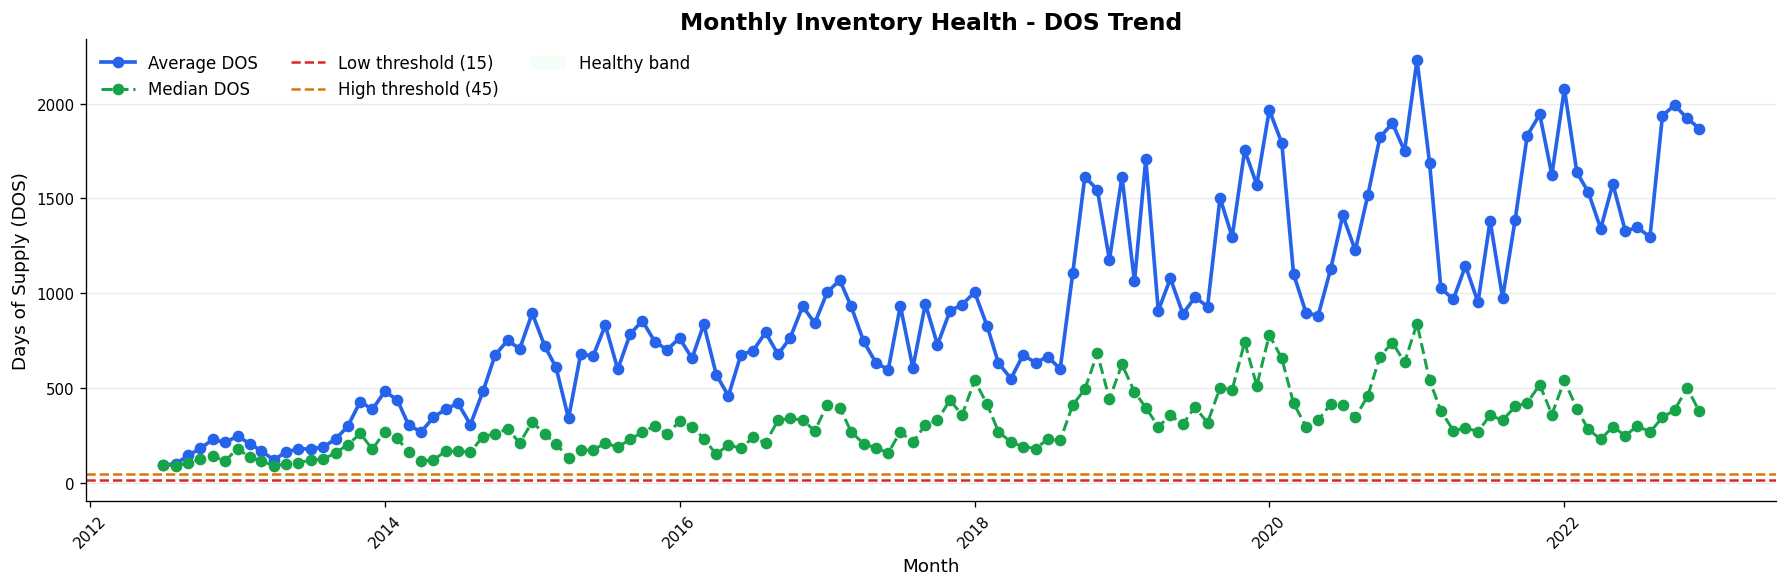

In [159]:
# ----- Chart 1: Monthly DOS trend with thresholds -----
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(monthly_kpi['month'], monthly_kpi['avg_dos'], marker='o', linewidth=2.2, color=PALETTE[0], label='Average DOS')
ax.plot(monthly_kpi['month'], monthly_kpi['median_dos'], marker='o', linewidth=1.8, linestyle='--', color=PALETTE[1], label='Median DOS')

ax.axhline(LOW_DOS, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Low threshold ({LOW_DOS})')
ax.axhline(HIGH_DOS, color='#d97706', linestyle='--', linewidth=1.5, label=f'High threshold ({HIGH_DOS})')

ax.fill_between(monthly_kpi['month'], LOW_DOS, HIGH_DOS, color='#dcfce7', alpha=0.25, label='Healthy band')

ax.set_title('Monthly Inventory Health - DOS Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Days of Supply (DOS)')
ax.grid(axis='y', alpha=0.25)
ax.legend(ncol=3, frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
from pathlib import Path
chart_dir = Path('./outputs/inventory_charts')
chart_dir.mkdir(parents=True, exist_ok=True)
out_path = chart_dir / 'inventory_monthly_dos_trend.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path.resolve()}")
plt.show()

Saved: C:\Users\Admin\Downloads\Vin Datathon\outputs\inventory_charts\inventory_monthly_stock_mix.png


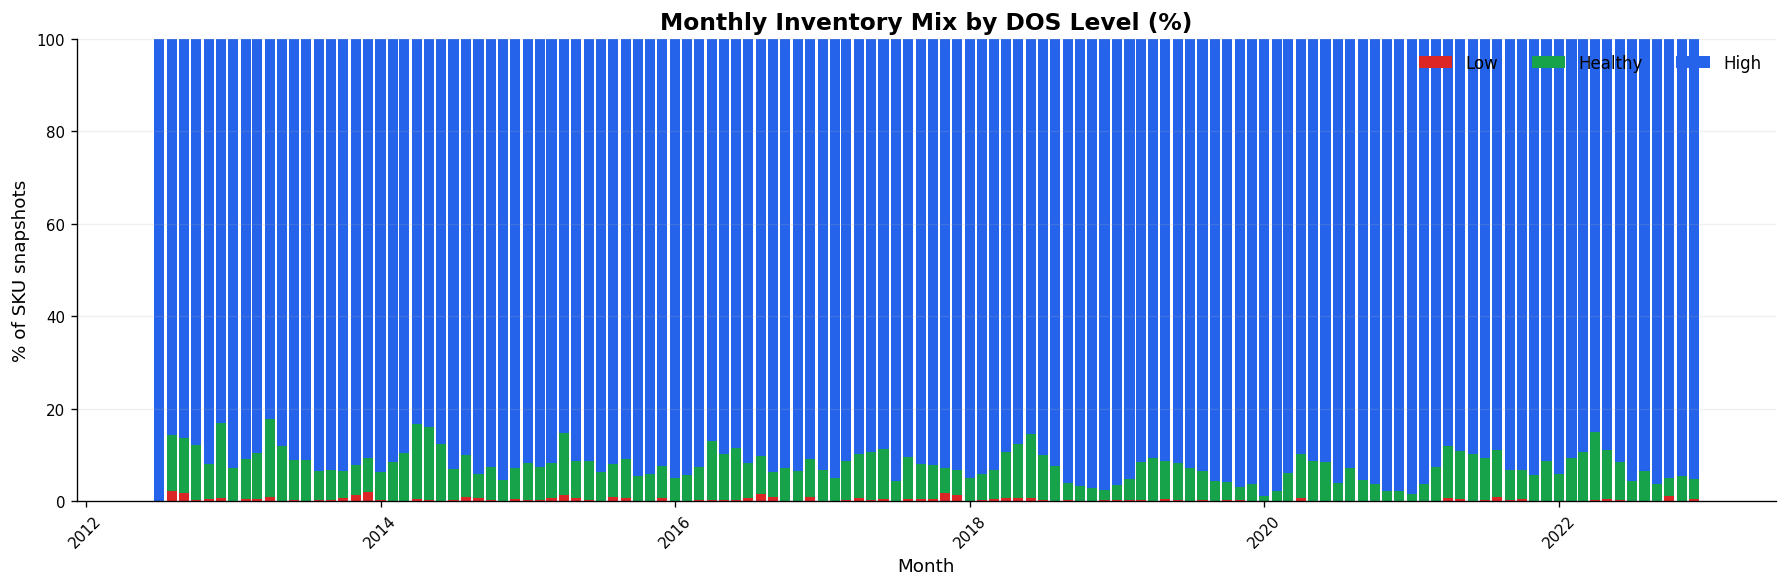

In [160]:
# ----- Chart 2: Monthly stock-level mix (stacked percentage) -----
status_mix = inv.groupby(['month', 'stock_level_by_dos']).size().unstack(fill_value=0)
status_mix_pct = status_mix.div(status_mix.sum(axis=1), axis=0) * 100

status_order = [c for c in ['Low', 'Healthy', 'High', 'Unknown'] if c in status_mix_pct.columns]
status_mix_pct = status_mix_pct.reindex(columns=status_order)

status_colors = {
    'Low': '#dc2626',
    'Healthy': '#16a34a',
    'High': '#2563eb',
    'Unknown': '#6b7280',
}

fig, ax = plt.subplots(figsize=(15, 5))
bottom = np.zeros(len(status_mix_pct))

for col in status_mix_pct.columns:
    vals = status_mix_pct[col].values
    ax.bar(status_mix_pct.index, vals, bottom=bottom, color=status_colors.get(col, '#9ca3af'), width=25, label=col)
    bottom += vals

ax.set_title('Monthly Inventory Mix by DOS Level (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('% of SKU snapshots')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.2)
ax.legend(frameon=False, ncol=4)
plt.xticks(rotation=45)
plt.tight_layout()
from pathlib import Path
chart_dir = Path('./outputs/inventory_charts')
chart_dir.mkdir(parents=True, exist_ok=True)
out_path = chart_dir / 'inventory_monthly_stock_mix.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved: {out_path.resolve()}")
plt.show()

Saved: C:\Users\Admin\Downloads\Vin Datathon\outputs\inventory_charts\inventory_segment_month_dos_heatmap.png


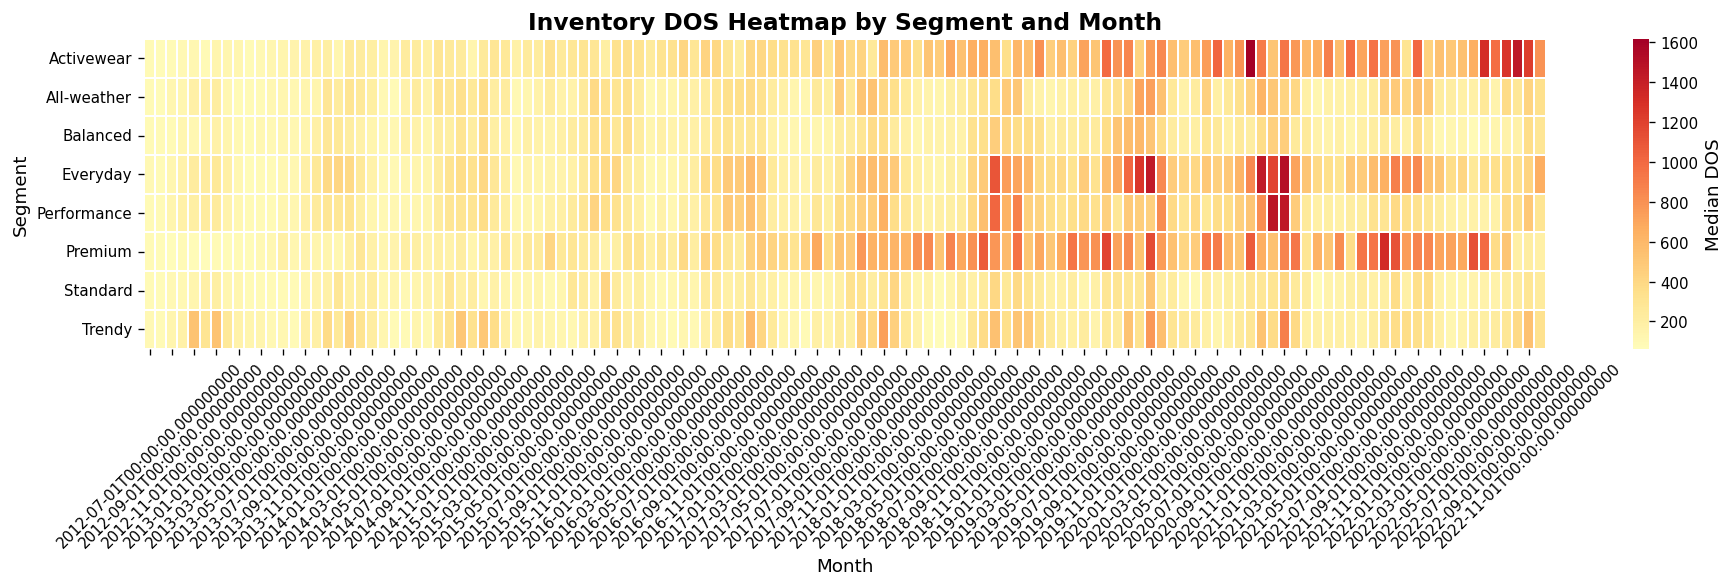

In [161]:
# ----- Chart 3: Segment x Month DOS heatmap -----
if 'segment' not in inv.columns:
    print("Column 'segment' not found in inventory -> skip heatmap.")
else:
    seg_month_dos = inv.pivot_table(
        index='segment',
        columns='month',
        values='dos',
        aggfunc='median'
    )

    plt.figure(figsize=(16, 5))
    sns.heatmap(
        seg_month_dos,
        cmap='RdYlGn_r',
        center=(LOW_DOS + HIGH_DOS) / 2,
        cbar_kws={'label': 'Median DOS'},
        linewidths=0.2
    )
    plt.title('Inventory DOS Heatmap by Segment and Month', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Segment')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    from pathlib import Path
    chart_dir = Path('./outputs/inventory_charts')
    chart_dir.mkdir(parents=True, exist_ok=True)
    out_path = chart_dir / 'inventory_segment_month_dos_heatmap.png'
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    print(f"Saved: {out_path.resolve()}")
    plt.show()

### Quick reading guide
- If **Average DOS** is below `15`: likely understock risk.
- If **Average DOS** is above `45`: likely overstock risk.
- In stacked chart, watch for rising **Low** (service risk) or **High** (cash tied in inventory).
- In heatmap, focus on segments staying red (high DOS) or very green with frequent stockout flags.